# 10 · Evaluación experimental, estabilidad y robustez del recomendador

En este notebook el objetivo es evaluar experimentalmente el comportamiento del sistema y comprobar si las recomendaciones obtenidas son eficientes, estables, diversas y robustas.

La evaluación responde a cuatro preguntas:

1. **¿Qué aporta el recomendador frente a reglas de referencia sencillas?**
2. **¿Cuánto cambia el resultado cuando se modifican ligeramente los pesos?**
3. **¿Qué ocurre al endurecer las restricciones de precio y tiempo?**
4. **¿Se mantienen las recomendaciones cuando los datos presentan pequeñas perturbaciones?**

Se comparan cinco estrategias:

- *pareto_weighted*: método principal del TFG, que recalcula Pareto y aplica una suma ponderada
- *weighted_all*: suma ponderada sin filtrar previamente las alternativas dominadas
- *ideal_distance*: distancia ponderada al punto ideal de precio y tiempo
- *cheapest*: selección basada únicamente en el menor precio
- *fastest*: selección basada únicamente en el menor tiempo diario

**NOTA:** El objetivo no es demostrar que un método gana siempre. En un problema multiobjetivo no existe una única solución universal. Lo importante es analizar qué estrategia representa mejor las preferencias del usuario y con qué estabilidad lo hace.

## 1. Importación de librerías

Se utilizan `pandas` y `numpy` para el análisis, `matplotlib` para las representaciones y utilidades estándar de Python para garantizar la reproducibilidad del experimento.

In [99]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype

In [100]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 180)

## 2. Reproducibilidad y configuración experimental

La semilla aleatoria permite repetir exactamente las perturbaciones del análisis de robustez.

*FAST_MODE* puede activarse durante una prueba rápida. 

**NOTA:** Para generar los resultados definitivos del TFG debe mantenerse en *False*

In [101]:
RANDOM_SEED = 42
RNG = np.random.default_rng(RANDOM_SEED)

In [102]:
# Modo reducido para comprobar que todas las celdas funcionan.
# Debe permanecer en False para la ejecución final del TFG.
FAST_MODE = False

TOP_K = 5
WEIGHT_STEP = 0.05 if FAST_MODE else 0.01
MONTE_CARLO_ITERATIONS = 40 if FAST_MODE else 250
NOISE_LEVELS = [0.02, 0.05, 0.10]

In [103]:
# Tolerancia utilizada en comparaciones con números decimales.
FLOAT_TOLERANCE = 1e-10

In [104]:
print("Semilla aleatoria:", RANDOM_SEED)
print("FAST_MODE:", FAST_MODE)
print("Paso de la rejilla de pesos:", WEIGHT_STEP)
print("Iteraciones Monte Carlo por escenario:", MONTE_CARLO_ITERATIONS)

Semilla aleatoria: 42
FAST_MODE: False
Paso de la rejilla de pesos: 0.01
Iteraciones Monte Carlo por escenario: 250


## 3. Localización del proyecto y archivos

La entrada principal es *pareto_by_destination.csv*. Los resultados de esta evaluación se guardan en *data/results*. 
**NOTA:** Los nombres comienzan por *evaluation_* para distinguirlos de los artefactos de los notebooks anteriores.

In [105]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto a partir del directorio actual."""

    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


In [106]:
PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = RESULTS_DIR / "pareto_by_destination.csv"

METHOD_DETAIL_PATH = RESULTS_DIR / "evaluation_method_comparison_detail.csv"
METHOD_SUMMARY_PATH = RESULTS_DIR / "evaluation_method_comparison_summary.csv"
WEIGHT_GRID_PATH = RESULTS_DIR / "evaluation_weight_stability_grid.csv"
WEIGHT_SUMMARY_PATH = RESULTS_DIR / "evaluation_weight_stability_summary.csv"
WEIGHT_INTERVALS_PATH = RESULTS_DIR / "evaluation_weight_stability_intervals.csv"
CONSTRAINT_DETAIL_PATH = RESULTS_DIR / "evaluation_constraint_robustness.csv"
CONSTRAINT_SUMMARY_PATH = RESULTS_DIR / "evaluation_constraint_robustness_summary.csv"
NOISE_FREQUENCY_PATH = RESULTS_DIR / "evaluation_noise_winner_frequency.csv"
NOISE_SUMMARY_PATH = RESULTS_DIR / "evaluation_noise_robustness_summary.csv"
DIVERSITY_PATH = RESULTS_DIR / "evaluation_diversity_summary.csv"
HYPOTHESES_PATH = RESULTS_DIR / "evaluation_hypotheses.csv"
VALIDATION_PATH = RESULTS_DIR / "evaluation_validation_report.csv"

In [107]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "No existe data/results/pareto_by_destination.csv. "
        "Ejecuta primero los notebooks 08 y 09."
    )


In [108]:
print("Raíz del proyecto:", PROJECT_ROOT)
print("Archivo de entrada:", INPUT_PATH.relative_to(PROJECT_ROOT))
print("Carpeta de resultados:", RESULTS_DIR.relative_to(PROJECT_ROOT))

Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Archivo de entrada: data\results\pareto_by_destination.csv
Carpeta de resultados: data\results


## 4. Carga y validación inicial de los datos

La evaluación necesita una fila única por combinación barrio–destino y valores válidos para los dos objetivos principales.

**NOTA:** Las columnas normalizadas del notebook 08 se validan, pero el notebook también puede volver a calcularlas cuando se perturban los valores originales.

In [109]:
data = pd.read_csv(INPUT_PATH)

In [110]:
PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

In [111]:
KEY_COLUMNS = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
]

In [112]:
REQUIRED_COLUMNS = KEY_COLUMNS + [
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
    "price_normalized",
    "time_normalized",
]

In [113]:
missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in data.columns
]

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias para la evaluación: "
        f"{missing_columns}"
    )

In [114]:
# Conversión explícita de los objetivos para evitar que una cadena o un separador decimal incorrecto pasen desapercibidos.
for column in [
    PRICE_COLUMN,
    TIME_COLUMN,
    "price_normalized",
    "time_normalized",
    "price_reliability_score",
]:
    if column in data.columns:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce",
        )

In [115]:
invalid_objectives = data[
    data[[PRICE_COLUMN, TIME_COLUMN]].isna().any(axis=1)
    | (data[[PRICE_COLUMN, TIME_COLUMN]] <= 0).any(axis=1)
]

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            KEY_COLUMNS + [PRICE_COLUMN, TIME_COLUMN]
        ]
    )
    raise ValueError(
        "Existen precios o tiempos nulos, no numéricos o no positivos."
    )

In [116]:
if data.duplicated(["zone_key", "destination_id"]).any():
    duplicates = data.loc[
        data.duplicated(
            ["zone_key", "destination_id"],
            keep=False,
        ),
        KEY_COLUMNS,
    ]
    display(duplicates)
    raise ValueError(
        "Hay combinaciones barrio–destino duplicadas."
    )

In [117]:
print("Dimensiones:", data.shape)
print("Barrios distintos:", data["zone_key"].nunique())
print("Destinos distintos:", data["destination_id"].nunique())

display(data.head())

Dimensiones: (371, 145)
Barrios distintos: 128
Destinos distintos: 3


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,neighborhood_name_transit,district_name_transit,destination_name,service_date,evening_route_status,morning_route_status,morning_start_datetime,morning_end_datetime,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,commute_daily_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,no_route_scenarios,route_status,route_available,route_missing_reason,usable_for_pareto_knn,is_pareto,dominated_by_count,price_normalized,time_normalized,distance_to_ideal,pareto_balance_rank
0,MAD-021,Imperial,Arganzuela,True,True,available,73,71,2,97.26,2.74,0.64,71,552415.49,515000.0,377000.00,699950.0,322950.00,168800.0,1257000.0,5807.42,5588.24,4756.76,6536.43,1779.68,1358.43,31.85,5443.04,5808.82,365.79,6.55,107.93,71,2000,0.95,calculated,96.25,107.0,62.50,128.00,65.50,37.0,190.0,2.62,3.0,71,0,100.00,1.82,2.0,11,60,15.49,0.8571,85.71,70,1,98.59,0.8000,80.00,70,1,98.59,56.35,92.06,47.22,68.35,medium,La estimación presenta una estabilidad intermedia en comparación con el resto de barrios.,residential_sale,asking_price,unknown,5855.12,6010.51,5776.45,110.77,119.22,108.30,100,102.65,98.66,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,504020100060,15,97.7,True,True,68.35,medium,5855.12,registered_transactions_2025,official_price_and

In [118]:
def parse_boolean_series(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    """Convierte una columna booleana exportada a CSV de forma segura."""

    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    true_values = {"true", "1", "yes", "y", "si", "sí"}
    false_values = {"false", "0", "no", "n"}
    valid_values = true_values | false_values

    invalid_mask = (
        normalized.notna()
        & ~normalized.isin(valid_values)
    )

    if invalid_mask.any():
        invalid_examples = sorted(
            normalized.loc[invalid_mask]
            .dropna()
            .unique()
            .tolist()
        )[:10]

        raise ValueError(
            f"Valores booleanos no reconocidos en {column_name}: "
            f"{invalid_examples}"
        )

    return normalized.isin(true_values).fillna(False)


data["is_pareto"] = parse_boolean_series(
    data["is_pareto"],
    "is_pareto",
)

In [119]:
normalized_columns = ["price_normalized", "time_normalized"]

if not (
    data[normalized_columns].ge(-FLOAT_TOLERANCE).all().all()
    and data[normalized_columns].le(1 + FLOAT_TOLERANCE).all().all()
):
    raise ValueError(
        "Las variables normalizadas deben encontrarse en el intervalo [0, 1]."
    )

coverage_summary = (
    data.groupby(
        ["destination_id", "destination_name"],
        as_index=False,
    )
    .agg(
        alternatives=("zone_key", "size"),
        neighborhoods=("zone_key", "nunique"),
        pareto_alternatives=("is_pareto", "sum"),
        price_min=(PRICE_COLUMN, "min"),
        price_median=(PRICE_COLUMN, "median"),
        price_max=(PRICE_COLUMN, "max"),
        time_min=(TIME_COLUMN, "min"),
        time_median=(TIME_COLUMN, "median"),
        time_max=(TIME_COLUMN, "max"),
    )
)

In [120]:
coverage_summary["pareto_percentage"] = (
    100
    * coverage_summary["pareto_alternatives"]
    / coverage_summary["alternatives"]
)

display(coverage_summary)

,destination_id,destination_name,alternatives,neighborhoods,pareto_alternatives,price_min,price_median,price_max,time_min,time_median,time_max,pareto_percentage
0,DEST_001,Puerta del Sol,119,119,13,1909.6,4736.60,14108.83,56.366667,117.6,244.516667,10.924370
1,DEST_002,Nuevos Ministerios,124,124,10,1909.6,4787.97,14108.83,44.966667,120.8,275.783333,8.064516
2,DEST_003,UC3M Campus de Leganés,128,128,5,1909.6,4884.51,14108.83,51.616667,202.6,328.300000,3.906250


## 5. Diseño experimental e hipótesis

Se utilizan los mismos tres perfiles definidos en el notebook 09:

| Perfil | Peso del precio | Peso del tiempo |
|---|---:|---:|
| Prioridad al precio | 0,75 | 0,25 |
| Equilibrado | 0,50 | 0,50 |
| Prioridad al tiempo | 0,25 | 0,75 |

La evaluación se apoya en las siguientes hipótesis operativas:

- **H1 - Eficiencia:** Todas las recomendaciones del método principal deben ser Pareto-eficientes dentro del conjunto compatible.
- **H2 - Estabilidad local:** Cambios pequeños y consecutivos en los pesos deberían conservar una parte elevada del *top 5*.
- **H3 - Robustez:** Con perturbaciones moderadas del 5 %, la recomendación base debería seguir apareciendo con frecuencia entre las cinco primeras.
- **H4 - Personalización:** Al menos un destino debería cambiar de primera recomendación entre los perfiles de precio, equilibrio y tiempo.
- **H5 - Restricciones:** Al endurecer precio y tiempo, el sistema debe conservar la eficiencia Pareto y gestionar correctamente los escenarios factibles o vacíos.

**NOTA:** Los umbrales utilizados al final no representan leyes universales. Son criterios explícitos para interpretar de forma reproducible los resultados del experimento.

In [121]:
PROFILES = {
    "price_priority": {
        "profile_name": "Prioridad al precio",
        "price_weight": 0.75,
        "time_weight": 0.25,
    },
    "balanced": {
        "profile_name": "Perfil equilibrado",
        "price_weight": 0.50,
        "time_weight": 0.50,
    },
    "time_priority": {
        "profile_name": "Prioridad al tiempo",
        "price_weight": 0.25,
        "time_weight": 0.75,
    },
}

In [122]:
METHOD_LABELS = {
    "pareto_weighted": "Pareto + suma ponderada",
    "weighted_all": "Suma ponderada sin filtro",
    "ideal_distance": "Distancia al punto ideal",
    "cheapest": "Barrio más barato",
    "fastest": "Trayecto más rápido",
}

In [123]:
METHODS = list(METHOD_LABELS)

In [124]:
destination_catalog = (
    data[["destination_id", "destination_name"]]
    .drop_duplicates()
    .sort_values(["destination_name", "destination_id"])
    .reset_index(drop=True)
)

profile_table = pd.DataFrame(
    [
        {"profile_id": profile_id, **values}
        for profile_id, values in PROFILES.items()
    ]
)

In [125]:
display(destination_catalog)

,destination_id,destination_name
0,DEST_002,Nuevos Ministerios
1,DEST_001,Puerta del Sol
2,DEST_003,UC3M Campus de Leganés


In [126]:

display(profile_table)

,profile_id,profile_name,price_weight,time_weight
0,price_priority,Prioridad al precio,0.75,0.25
1,balanced,Perfil equilibrado,0.50,0.50
2,time_priority,Prioridad al tiempo,0.25,0.75


## 6. Funciones comunes de evaluación

Las funciones siguientes separan claramente cuatro tareas:

1. Normalizar los objetivos;
2. Identificar alternativas no dominadas;
3. Generar rankings con distintos métodos;
4. Calcular métricas comparables.

**NOTA:** La implementación de Pareto está especializada en dos objetivos y conserva como eficientes los empates exactos.

In [127]:
def normalize_weights(
    price_weight: float,
    time_weight: float,
) -> tuple[float, float]:
    """Valida los pesos y fuerza que su suma sea igual a uno."""

    weights = np.asarray(
        [price_weight, time_weight],
        dtype=float,
    )

    if not np.isfinite(weights).all():
        raise ValueError("Los pesos deben ser finitos.")

    if (weights < 0).any():
        raise ValueError("Los pesos no pueden ser negativos.")

    total = weights.sum()

    if np.isclose(total, 0):
        raise ValueError("Al menos uno de los pesos debe ser positivo.")

    return (
        float(weights[0] / total),
        float(weights[1] / total),
    )

In [128]:
def minmax_normalize(series: pd.Series) -> pd.Series:
    """Normalización min-max robusta para una serie numérica."""

    numeric = pd.to_numeric(series, errors="coerce").astype(float)
    minimum = numeric.min()
    maximum = numeric.max()

    if not np.isfinite(minimum) or not np.isfinite(maximum):
        raise ValueError("No se puede normalizar una serie con valores no finitos.")

    if np.isclose(maximum, minimum):
        # Cuando todos los valores son iguales, ninguna alternativa
        # obtiene ventaja por este objetivo.
        return pd.Series(
            np.zeros(len(numeric), dtype=float),
            index=numeric.index,
        )

    return (numeric - minimum) / (maximum - minimum)

In [129]:


def resolve_destination_id(
    source: pd.DataFrame,
    destination: str | int,
) -> object:
    """Permite seleccionar un destino por identificador o por nombre."""

    catalog = source[
        ["destination_id", "destination_name"]
    ].drop_duplicates()

    requested = str(destination).strip().casefold()

    match = catalog.loc[
        catalog["destination_id"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
        |
        catalog["destination_name"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(requested)
    ]

    if match.empty:
        raise KeyError(f"Destino no encontrado: {destination}")

    if len(match) > 1:
        raise ValueError(
            "El destino no es unívoco. Utiliza destination_id."
        )

    return match.iloc[0]["destination_id"]

In [130]:
def pareto_mask_2d(
    price_values: Iterable[float],
    time_values: Iterable[float],
) -> np.ndarray:
    """
    Devuelve una máscara de eficiencia Pareto para dos objetivos a minimizar. Un punto está dominado cuando existe otro con precio y tiempo no mayores,
    y con al menos uno de los dos valores estrictamente menor.
    """

    price = np.asarray(price_values, dtype=float)
    time = np.asarray(time_values, dtype=float)

    if price.ndim != 1 or time.ndim != 1 or len(price) != len(time):
        raise ValueError("Los dos objetivos deben ser vectores de igual longitud.")

    if not np.isfinite(price).all() or not np.isfinite(time).all():
        raise ValueError("Pareto no admite NaN o infinitos.")

    if len(price) == 0:
        return np.array([], dtype=bool)

    # Orden lexicográfico: primero precio y después tiempo.
    order = np.lexsort((time, price))
    sorted_price = price[order]
    sorted_time = time[order]
    efficient_sorted = np.zeros(len(price), dtype=bool)

    best_time_lower_price = np.inf
    start = 0

    while start < len(price):
        end = start + 1

        # Se agrupan precios exactamente iguales. Así se puede distinguir entre dominación por un precio inferior y por el mismo precio.
        while (
            end < len(price)
            and sorted_price[end] == sorted_price[start]
        ):
            end += 1

        group_times = sorted_time[start:end]
        group_min_time = group_times.min()

        # Solo son eficientes los mínimos de tiempo del grupo, siempre que ningún punto con precio inferior alcance un tiempo igual o menor.
        efficient_sorted[start:end] = (
            (group_times == group_min_time)
            & (group_times < best_time_lower_price)
        )

        best_time_lower_price = min(
            best_time_lower_price,
            group_min_time,
        )
        start = end

    efficient = np.zeros(len(price), dtype=bool)
    efficient[order] = efficient_sorted
    return efficient


In [131]:
def build_destination_frame(
    source: pd.DataFrame,
    destination: str | int,
    price_values: np.ndarray | pd.Series | None = None,
    time_values: np.ndarray | pd.Series | None = None,
) -> pd.DataFrame:
    """
    Prepara las alternativas de un destino.

    `price_values` y `time_values` se utilizan en el experimento de ruido. Cuando no se proporcionan, se conservan los valores originales.
    """

    destination_id = resolve_destination_id(source, destination)

    frame = (
        source.loc[
            source["destination_id"].astype(str).eq(str(destination_id))
        ]
        .copy()
        .reset_index(drop=True)
    )

    if frame.empty:
        raise ValueError("El destino no tiene alternativas disponibles.")

    if price_values is not None:
        values = np.asarray(price_values, dtype=float)
        if len(values) != len(frame):
            raise ValueError("price_values tiene una longitud incorrecta.")
        frame[PRICE_COLUMN] = values

    if time_values is not None:
        values = np.asarray(time_values, dtype=float)
        if len(values) != len(frame):
            raise ValueError("time_values tiene una longitud incorrecta.")
        frame[TIME_COLUMN] = values

    # Las escalas se calculan antes de aplicar restricciones. De este modo, un filtro no cambia artificialmente la posición relativa de los barrios.
    frame["evaluation_price_normalized"] = minmax_normalize(
        frame[PRICE_COLUMN]
    )
    frame["evaluation_time_normalized"] = minmax_normalize(
        frame[TIME_COLUMN]
    )

    return frame


In [132]:
def rank_alternatives(
    source: pd.DataFrame,
    destination: str | int,
    method: str,
    price_weight: float,
    time_weight: float,
    top_n: int = TOP_K,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    min_price_reliability_score: float | None = None,
    price_values: np.ndarray | pd.Series | None = None,
    time_values: np.ndarray | pd.Series | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Genera un ranking comparable para cualquiera de los métodos."""

    if method not in METHODS:
        raise ValueError(f"Método no reconocido: {method}")

    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError("top_n debe ser un entero positivo.")

    price_weight, time_weight = normalize_weights(
        price_weight,
        time_weight,
    )

    frame = build_destination_frame(
        source=source,
        destination=destination,
        price_values=price_values,
        time_values=time_values,
    )

    alternatives_before_filters = len(frame)

    mask = pd.Series(True, index=frame.index)

    if max_price_m2 is not None:
        if not np.isfinite(max_price_m2) or max_price_m2 <= 0:
            raise ValueError("max_price_m2 debe ser positivo.")
        mask &= frame[PRICE_COLUMN].le(float(max_price_m2))

    if max_commute_daily_minutes is not None:
        if (
            not np.isfinite(max_commute_daily_minutes)
            or max_commute_daily_minutes <= 0
        ):
            raise ValueError(
                "max_commute_daily_minutes debe ser positivo."
            )
        mask &= frame[TIME_COLUMN].le(
            float(max_commute_daily_minutes)
        )

    if min_price_reliability_score is not None:
        if "price_reliability_score" not in frame.columns:
            raise KeyError(
                "No existe price_reliability_score en el dataset."
            )

        threshold = float(min_price_reliability_score)

        if not 0 <= threshold <= 100:
            raise ValueError(
                "min_price_reliability_score debe estar entre 0 y 100."
            )

        mask &= frame["price_reliability_score"].ge(threshold)

    eligible = frame.loc[mask].copy()

    audit = {
        "alternatives_before_filters": alternatives_before_filters,
        "eligible_alternatives": len(eligible),
        "removed_alternatives": alternatives_before_filters - len(eligible),
    }

    if eligible.empty:
        return eligible, audit

    eligible["is_pareto_eligible"] = pareto_mask_2d(
        eligible[PRICE_COLUMN],
        eligible[TIME_COLUMN],
    )

    if method == "pareto_weighted":
        candidates = eligible.loc[
            eligible["is_pareto_eligible"]
        ].copy()

        candidates["method_score"] = (
            price_weight
            * candidates["evaluation_price_normalized"]
            + time_weight
            * candidates["evaluation_time_normalized"]
        )

    elif method == "weighted_all":
        candidates = eligible.copy()
        candidates["method_score"] = (
            price_weight
            * candidates["evaluation_price_normalized"]
            + time_weight
            * candidates["evaluation_time_normalized"]
        )

    elif method == "ideal_distance":
        candidates = eligible.copy()
        candidates["method_score"] = np.sqrt(
            price_weight
            * candidates["evaluation_price_normalized"] ** 2
            + time_weight
            * candidates["evaluation_time_normalized"] ** 2
        )

    elif method == "cheapest":
        candidates = eligible.copy()
        candidates["method_score"] = (
            candidates["evaluation_price_normalized"]
            + 1e-9
            * candidates["evaluation_time_normalized"]
        )

    else:  # fastest
        candidates = eligible.copy()
        candidates["method_score"] = (
            candidates["evaluation_time_normalized"]
            + 1e-9
            * candidates["evaluation_price_normalized"]
        )

    # Métricas comunes, aunque cada método utilice una regla de ordenación.
    candidates["personalized_score"] = (
        price_weight
        * candidates["evaluation_price_normalized"]
        + time_weight
        * candidates["evaluation_time_normalized"]
    )

    candidates["ideal_distance"] = np.sqrt(
        price_weight
        * candidates["evaluation_price_normalized"] ** 2
        + time_weight
        * candidates["evaluation_time_normalized"] ** 2
    )

    candidates["method"] = method
    candidates["method_label"] = METHOD_LABELS[method]
    candidates["price_weight"] = price_weight
    candidates["time_weight"] = time_weight

    # Los desempates se resuelven de forma determinista.
    sort_columns = [
        "method_score",
        "personalized_score",
        "ideal_distance",
    ]
    sort_ascending = [True, True, True]

    if "price_reliability_score" in candidates.columns:
        sort_columns.append("price_reliability_score")
        sort_ascending.append(False)

    sort_columns.extend(
        [PRICE_COLUMN, TIME_COLUMN, "zone_key"]
    )
    sort_ascending.extend([True, True, True])

    candidates = (
        candidates.sort_values(
            sort_columns,
            ascending=sort_ascending,
            kind="mergesort",
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    candidates["rank"] = np.arange(1, len(candidates) + 1)
    audit["pareto_eligible_alternatives"] = int(
        eligible["is_pareto_eligible"].sum()
    )
    audit["returned_alternatives"] = len(candidates)

    return candidates, audit

In [133]:
def jaccard_at_k(
    first: Iterable[object],
    second: Iterable[object],
) -> float:
    """Similitud de Jaccard entre dos listas tratadas como conjuntos."""

    set_first = set(first)
    set_second = set(second)
    union = set_first | set_second

    if not union:
        return 1.0

    return len(set_first & set_second) / len(union)

In [134]:
def normalized_entropy(counts: pd.Series) -> float:
    """Entropía entre 0 y 1 de una distribución de frecuencias."""

    probabilities = counts.astype(float) / counts.sum()
    probabilities = probabilities[probabilities > 0]

    if len(probabilities) <= 1:
        return 0.0

    entropy = -float(np.sum(probabilities * np.log(probabilities)))
    return entropy / math.log(len(probabilities))

## 7. Comprobación independiente de Pareto

Antes de comparar métodos, se verifica que la implementación utilizada en este notebook reproduce la etiqueta *is_pareto* del notebook 08. Esta prueba es importante porque la eficiencia constituye una parte central del recomendador.

In [135]:
pareto_reproduction_rows = []

for destination_id in destination_catalog["destination_id"]:
    destination_frame = build_destination_frame(
        data,
        destination_id,
    )

    reproduced = pareto_mask_2d(
        destination_frame[PRICE_COLUMN],
        destination_frame[TIME_COLUMN],
    )

    expected = destination_frame["is_pareto"].to_numpy(dtype=bool)

    pareto_reproduction_rows.append(
        {
            "destination_id": destination_id,
            "destination_name": destination_frame[
                "destination_name"
            ].iloc[0],
            "rows": len(destination_frame),
            "expected_pareto": int(expected.sum()),
            "reproduced_pareto": int(reproduced.sum()),
            "matching_rows": int((expected == reproduced).sum()),
            "match_percentage": 100 * float(np.mean(expected == reproduced)),
        }
    )

In [136]:
pareto_reproduction = pd.DataFrame(pareto_reproduction_rows)
display(pareto_reproduction)

if not np.isclose(
    pareto_reproduction["match_percentage"],
    100,
).all():
    raise AssertionError(
        "La comprobación independiente no reproduce todas las etiquetas Pareto."
    )

print("La frontera de Pareto se reproduce correctamente en todos los destinos.")

,destination_id,destination_name,rows,expected_pareto,reproduced_pareto,matching_rows,match_percentage
0,DEST_002,Nuevos Ministerios,124,10,10,124,100.0
1,DEST_001,Puerta del Sol,119,13,13,119,100.0
2,DEST_003,UC3M Campus de Leganés,128,5,5,128,100.0


La frontera de Pareto se reproduce correctamente en todos los destinos.


## 8. Comparación con métodos de referencia

Para cada combinación destino–perfil se obtiene un *top 5* con los cinco métodos.

Todos los rankings se evalúan con las mismas métricas, incluso cuando el método no utiliza directamente los pesos del perfil. Esto permite medir el coste de aplicar una regla fija.

**EJEMPLO:** elegir siempre el barrio más barato— a usuarios con preferencias distintas.

In [137]:
method_detail_rows = []

for destination_id in destination_catalog["destination_id"]:
    for profile_id, profile in PROFILES.items():
        for method in METHODS:
            ranking, audit = rank_alternatives(
                source=data,
                destination=destination_id,
                method=method,
                price_weight=profile["price_weight"],
                time_weight=profile["time_weight"],
                top_n=TOP_K,
            )

            for _, row in ranking.iterrows():
                method_detail_rows.append(
                    {
                        "destination_id": row["destination_id"],
                        "destination_name": row["destination_name"],
                        "profile_id": profile_id,
                        "profile_name": profile["profile_name"],
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "price_weight": profile["price_weight"],
                        "time_weight": profile["time_weight"],
                        "rank": int(row["rank"]),
                        "zone_key": row["zone_key"],
                        "neighborhood_name": row["neighborhood_name"],
                        "district_name": row["district_name"],
                        PRICE_COLUMN: row[PRICE_COLUMN],
                        TIME_COLUMN: row[TIME_COLUMN],
                        "personalized_score": row["personalized_score"],
                        "ideal_distance": row["ideal_distance"],
                        "is_pareto_eligible": bool(
                            row["is_pareto_eligible"]
                        ),
                        "eligible_alternatives": audit[
                            "eligible_alternatives"
                        ],
                    }
                )

In [138]:
method_comparison_detail = pd.DataFrame(method_detail_rows)

display(
    method_comparison_detail.head(15)
)

,destination_id,destination_name,profile_id,profile_name,method,method_label,price_weight,time_weight,rank,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,personalized_score,ideal_distance,is_pareto_eligible,eligible_alternatives
0,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,1,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,0.118201,0.169199,True,124
1,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,2,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,0.136683,0.138734,True,124
2,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,3,MAD-172,San Cristóbal,Villaverde,1909.60,174.283333,0.140064,0.280129,True,124
3,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,4,MAD-206,Rejas,San Blas - Canillejas,3580.16,82.266667,0.143105,0.143503,True,124
4,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,pareto_weighted,Pareto + suma ponderada,0.75,0.25,5,MAD-131,Entrevías,Puente de Vallecas,2430.16,150.166667,0.145947,0.230863,True,124
5,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,1,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,0.118201,0.169199,True,124
6,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,2,MAD-203,Amposta,San Blas - Canillejas,2544.10,128.016667,0.128961,0.185458,False,124
7,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,3,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,0.136683,0.138734,True,124
8,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,4,MAD-172,San Cristóbal,Villaverde,1909.60,174.283333,0.140064,0.280129,True,124
9,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,weighted_all,Suma ponderada sin filtro,0.75,0.25,5,MAD-206,Rejas,San Blas - Canillejas,3580.16,82.266667,0.143105,0.143503,True,124


In [139]:
top1_method_results = method_comparison_detail.loc[
    method_comparison_detail["rank"].eq(1)
].copy()

In [140]:
method_comparison_summary = (
    method_comparison_detail.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        evaluated_recommendations=("zone_key", "size"),
        mean_personalized_score=("personalized_score", "mean"),
        median_personalized_score=("personalized_score", "median"),
        mean_ideal_distance=("ideal_distance", "mean"),
        pareto_efficiency_rate=("is_pareto_eligible", "mean"),
        unique_neighborhoods_top5=("zone_key", "nunique"),
        unique_districts_top5=("district_name", "nunique"),
    )
)

In [141]:
method_top1_summary = (
    top1_method_results.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        scenarios=("zone_key", "size"),
        mean_top1_personalized_score=("personalized_score", "mean"),
        mean_top1_ideal_distance=("ideal_distance", "mean"),
        pareto_top1_rate=("is_pareto_eligible", "mean"),
        unique_top1_neighborhoods=("zone_key", "nunique"),
        unique_top1_districts=("district_name", "nunique"),
    )
)

In [142]:
method_comparison_summary = method_comparison_summary.merge(
    method_top1_summary,
    on=["method", "method_label"],
    how="left",
    validate="one_to_one",
)

In [143]:
for column in ["pareto_efficiency_rate", "pareto_top1_rate"]:
    method_comparison_summary[column] *= 100

In [144]:
method_comparison_summary = method_comparison_summary.sort_values(
    ["mean_top1_personalized_score", "mean_top1_ideal_distance"]
).reset_index(drop=True)

In [145]:
display(method_comparison_summary)

,method,method_label,evaluated_recommendations,mean_personalized_score,median_personalized_score,mean_ideal_distance,pareto_efficiency_rate,unique_neighborhoods_top5,unique_districts_top5,scenarios,mean_top1_personalized_score,mean_top1_ideal_distance,pareto_top1_rate,unique_top1_neighborhoods,unique_top1_districts
0,pareto_weighted,Pareto + suma ponderada,45,0.121629,0.125486,0.152397,100.000000,20,8,9,0.089911,0.137070,100.0,5,5
1,weighted_all,Suma ponderada sin filtro,45,0.113148,0.110749,0.140309,77.777778,25,9,9,0.089911,0.137070,100.0,5,5
2,ideal_distance,Distancia al punto ideal,45,0.119590,0.128961,0.130714,73.333333,21,8,9,0.098440,0.111562,100.0,7,4
3,cheapest,Barrio más barato,45,0.253268,0.229640,0.326732,53.333333,5,4,9,0.218240,0.301627,100.0,1,1
4,fastest,Trayecto más rápido,45,0.210507,0.146311,0.270806,66.666667,15,7,9,0.306946,0.424226,100.0,3,3


### 8.1 Análisis de la comparación

La siguiente celda genera un comentario a partir de los resultados reales. Se distingue entre el rendimiento de la primera recomendación y la calidad del conjunto completo de cinco alternativas.

In [146]:
best_personalized_method = method_comparison_summary.iloc[0]
pareto_method_summary = method_comparison_summary.loc[
    method_comparison_summary["method"].eq("pareto_weighted")
].iloc[0]
weighted_all_summary = method_comparison_summary.loc[
    method_comparison_summary["method"].eq("weighted_all")
].iloc[0]

In [147]:
same_top1_pareto_weighted = (
    top1_method_results.loc[
        top1_method_results["method"].isin(
            ["pareto_weighted", "weighted_all"]
        )
    ]
    .pivot_table(
        index=["destination_id", "profile_id"],
        columns="method",
        values="zone_key",
        aggfunc="first",
    )
    .dropna()
)

In [148]:
same_top1_rate = 100 * (
    same_top1_pareto_weighted["pareto_weighted"]
    == same_top1_pareto_weighted["weighted_all"]
).mean()

In [149]:
display(
    Markdown(
        f"""
El método con menor puntuación personalizada media en la primera posición es **{best_personalized_method['method_label']}**, con un valor de **{best_personalized_method['mean_top1_personalized_score']:.4f}**.

El método principal, **Pareto + suma ponderada**, alcanza una tasa de eficiencia del **{pareto_method_summary['pareto_top1_rate']:.2f} %** en la primera recomendación y utiliza **{int(pareto_method_summary['unique_neighborhoods_top5'])} barrios distintos** en el conjunto de resultados evaluados.

La primera recomendación de `pareto_weighted` y `weighted_all` coincide en el **{same_top1_rate:.2f} %** de los escenarios. Esta coincidencia es coherente con la teoría: una suma ponderada con pesos no negativos no debería elegir como primera opción una alternativa estrictamente dominada. El filtrado de Pareto aporta sobre todo **trazabilidad, reducción del conjunto y protección del top completo frente a opciones dominadas**, aunque no siempre cambie el ganador de la suma ponderada.

Las reglas `cheapest` y `fastest` sirven como extremos interpretables. Su resultado puede ser adecuado para perfiles muy especializados, pero su puntuación empeora cuando se aplican a usuarios que valoran el otro objetivo.
"""
    )
)


El método con menor puntuación personalizada media en la primera posición es **Pareto + suma ponderada**, con un valor de **0.0899**.

El método principal, **Pareto + suma ponderada**, alcanza una tasa de eficiencia del **100.00 %** en la primera recomendación y utiliza **20 barrios distintos** en el conjunto de resultados evaluados.

La primera recomendación de `pareto_weighted` y `weighted_all` coincide en el **100.00 %** de los escenarios. Esta coincidencia es coherente con la teoría: una suma ponderada con pesos no negativos no debería elegir como primera opción una alternativa estrictamente dominada. El filtrado de Pareto aporta sobre todo **trazabilidad, reducción del conjunto y protección del top completo frente a opciones dominadas**, aunque no siempre cambie el ganador de la suma ponderada.

Las reglas `cheapest` y `fastest` sirven como extremos interpretables. Su resultado puede ser adecuado para perfiles muy especializados, pero su puntuación empeora cuando se aplican a usuarios que valoran el otro objetivo.


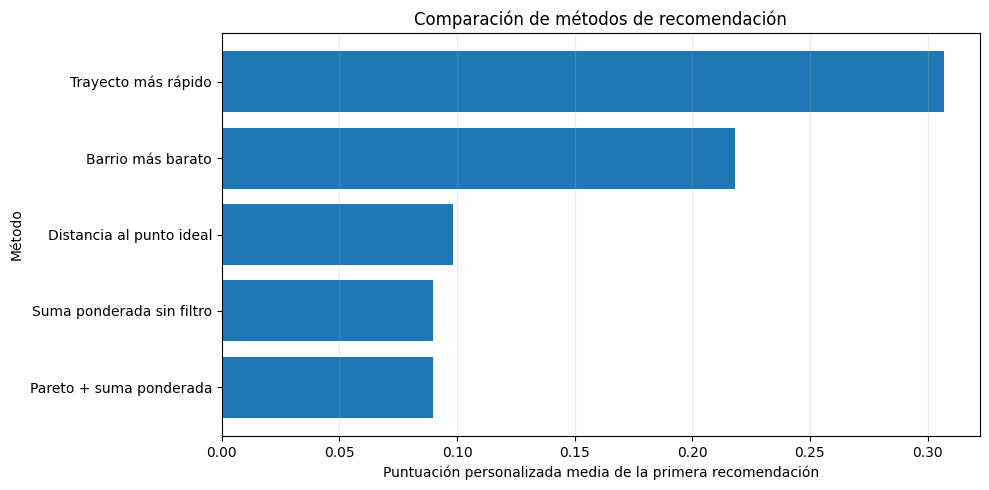

In [150]:
plot_data = method_comparison_summary.sort_values(
    "mean_top1_personalized_score",
    ascending=True,
)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["method_label"],
    plot_data["mean_top1_personalized_score"],
)
plt.xlabel("Puntuación personalizada media de la primera recomendación")
plt.ylabel("Método")
plt.title("Comparación de métodos de recomendación")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

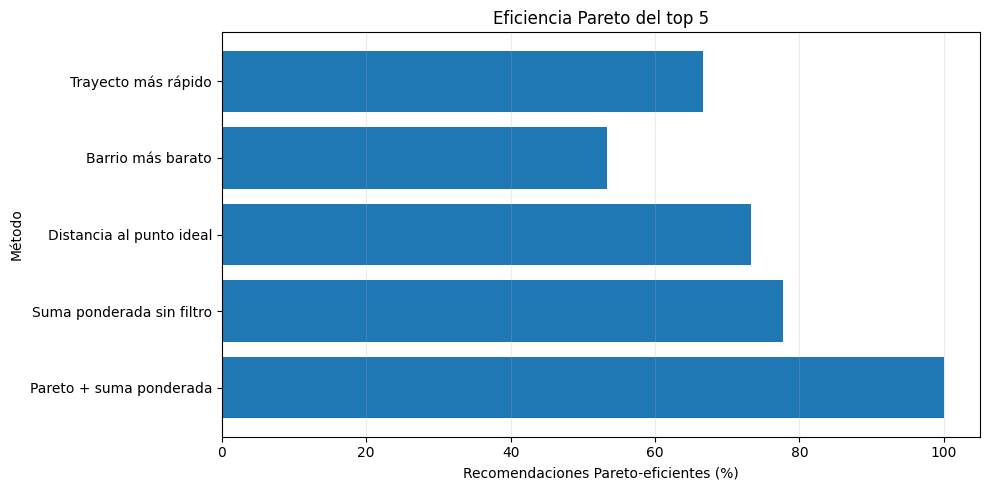

In [151]:
plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["method_label"],
    plot_data["pareto_efficiency_rate"],
)
plt.xlabel("Recomendaciones Pareto-eficientes (%)")
plt.ylabel("Método")
plt.title(f"Eficiencia Pareto del top {TOP_K}")
plt.xlim(0, 105)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Diversidad y cobertura de las recomendaciones

EL sistema personalizado no debería devolver siempre el mismo barrio independientemente del usuario.

Se analizan tres dimensiones:

- **Cobertura de catálogo:** Proporción de barrios que aparecen al menos una vez;
- **Diversidad de distritos:** Número de distritos representados;
- **Dependencia del perfil:** Destinos en los que cambia la primera recomendación al cambiar los pesos.

In [152]:
total_neighborhoods = data["zone_key"].nunique()
total_districts = data["district_name"].nunique()

In [153]:
diversity_summary = (
    method_comparison_detail.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        unique_neighborhoods=("zone_key", "nunique"),
        unique_districts=("district_name", "nunique"),
    )
)

In [154]:
diversity_summary["catalog_coverage_pct"] = (
    100 * diversity_summary["unique_neighborhoods"] / total_neighborhoods
)

In [155]:
diversity_summary["district_coverage_pct"] = (
    100 * diversity_summary["unique_districts"] / total_districts
)

In [156]:
profile_dependence_rows = []

for method in METHODS:
    method_top1 = top1_method_results.loc[
        top1_method_results["method"].eq(method)
    ]

    for (
        destination_id,
        destination_name,
    ), group in method_top1.groupby(
        ["destination_id", "destination_name"]
    ):
        profile_dependence_rows.append(
            {
                "method": method,
                "method_label": METHOD_LABELS[method],
                "destination_id": destination_id,
                "destination_name": destination_name,
                "unique_top1_across_profiles": group[
                    "zone_key"
                ].nunique(),
                "changes_with_profile": group[
                    "zone_key"
                ].nunique() > 1,
            }
        )

In [157]:
profile_dependence = pd.DataFrame(profile_dependence_rows)

profile_dependence_summary = (
    profile_dependence.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        destinations_evaluated=("destination_id", "nunique"),
        destinations_changing_with_profile=(
            "changes_with_profile",
            "sum",
        ),
        mean_unique_top1_across_profiles=(
            "unique_top1_across_profiles",
            "mean",
        ),
    )
)

In [158]:
diversity_summary = diversity_summary.merge(
    profile_dependence_summary,
    on=["method", "method_label"],
    how="left",
    validate="one_to_one",
)

In [159]:
display(diversity_summary)

,method,method_label,unique_neighborhoods,unique_districts,catalog_coverage_pct,district_coverage_pct,destinations_evaluated,destinations_changing_with_profile,mean_unique_top1_across_profiles
0,cheapest,Barrio más barato,5,4,3.90625,19.047619,3,0,1.000000
1,fastest,Trayecto más rápido,15,7,11.71875,33.333333,3,0,1.000000
2,ideal_distance,Distancia al punto ideal,21,8,16.40625,38.095238,3,3,2.333333
3,pareto_weighted,Pareto + suma ponderada,20,8,15.62500,38.095238,3,3,2.000000
4,weighted_all,Suma ponderada sin filtro,25,9,19.53125,42.857143,3,3,2.000000


In [160]:
display(profile_dependence)

,method,method_label,destination_id,destination_name,unique_top1_across_profiles,changes_with_profile
0,pareto_weighted,Pareto + suma ponderada,DEST_001,Puerta del Sol,2,True
1,pareto_weighted,Pareto + suma ponderada,DEST_002,Nuevos Ministerios,2,True
2,pareto_weighted,Pareto + suma ponderada,DEST_003,UC3M Campus de Leganés,2,True
3,weighted_all,Suma ponderada sin filtro,DEST_001,Puerta del Sol,2,True
4,weighted_all,Suma ponderada sin filtro,DEST_002,Nuevos Ministerios,2,True
5,weighted_all,Suma ponderada sin filtro,DEST_003,UC3M Campus de Leganés,2,True
6,ideal_distance,Distancia al punto ideal,DEST_001,Puerta del Sol,2,True
7,ideal_distance,Distancia al punto ideal,DEST_002,Nuevos Ministerios,3,True
8,ideal_distance,Distancia al punto ideal,DEST_003,UC3M Campus de Leganés,2,True
9,cheapest,Barrio más barato,DEST_001,Puerta del Sol,1,False


In [161]:
main_diversity = diversity_summary.loc[
    diversity_summary["method"].eq("pareto_weighted")
].iloc[0]

In [162]:
main_profile_dependence = profile_dependence.loc[
    profile_dependence["method"].eq("pareto_weighted")
]

In [163]:
changing_destinations = main_profile_dependence.loc[
    main_profile_dependence["changes_with_profile"],
    "destination_name",
].tolist()

In [164]:
changing_text = (
    ", ".join(changing_destinations)
    if changing_destinations
    else "ningún destino"
)

In [165]:
display(
    Markdown(
        f"""
El método principal utiliza **{int(main_diversity['unique_neighborhoods'])} barrios distintos**, equivalentes al **{main_diversity['catalog_coverage_pct']:.2f} %** del catálogo disponible en el dataset de evaluación. También representa **{int(main_diversity['unique_districts'])} distritos**.

La primera recomendación cambia entre perfiles en **{int(main_diversity['destinations_changing_with_profile'])} de {int(main_diversity['destinations_evaluated'])} destinos**: {changing_text}.

Este resultado permite comprobar si la personalización tiene un efecto real. Si todos los perfiles recibieran exactamente el mismo ganador, los pesos existirían en la interfaz, pero no estarían modificando la decisión final.
"""
    )
)


El método principal utiliza **20 barrios distintos**, equivalentes al **15.62 %** del catálogo disponible en el dataset de evaluación. También representa **8 distritos**.

La primera recomendación cambia entre perfiles en **3 de 3 destinos**: Puerta del Sol, Nuevos Ministerios, UC3M Campus de Leganés.

Este resultado permite comprobar si la personalización tiene un efecto real. Si todos los perfiles recibieran exactamente el mismo ganador, los pesos existirían en la interfaz, pero no estarían modificando la decisión final.


## 10. Estabilidad ante cambios en los pesos

Se recorre todo el intervalo del peso del precio entre 0 y 1. El peso del tiempo se calcula como **1 - peso_precio**.

Para cada punto se guarda:

- La primera recomendación
- El *top 5* completo
- La similitud de Jaccard con el punto anterior
- Los intervalos de pesos en los que el ganador permanece constante

Una transición no es necesariamente un error. Puede indicar que dos barrios representan compromisos distintos y que existe un umbral razonable en el que cambia la preferencia.

In [166]:
number_of_weight_steps = int(round(1 / WEIGHT_STEP))
weight_values = np.linspace(0, 1, number_of_weight_steps + 1)

weight_grid_rows = []

In [167]:
for destination_id in destination_catalog["destination_id"]:
    previous_top_k: list[str] | None = None
    previous_top1: str | None = None

    for price_weight in weight_values:
        time_weight = 1 - float(price_weight)

        ranking, _ = rank_alternatives(
            source=data,
            destination=destination_id,
            method="pareto_weighted",
            price_weight=float(price_weight),
            time_weight=time_weight,
            top_n=TOP_K,
        )

        top_k = ranking["zone_key"].astype(str).tolist()
        top1 = top_k[0] if top_k else None

        weight_grid_rows.append(
            {
                "destination_id": ranking["destination_id"].iloc[0],
                "destination_name": ranking["destination_name"].iloc[0],
                "price_weight": float(price_weight),
                "time_weight": time_weight,
                "top1_zone_key": top1,
                "top1_neighborhood_name": (
                    ranking["neighborhood_name"].iloc[0]
                    if not ranking.empty
                    else None
                ),
                "top1_price_m2": (
                    ranking[PRICE_COLUMN].iloc[0]
                    if not ranking.empty
                    else np.nan
                ),
                "top1_commute_daily_minutes": (
                    ranking[TIME_COLUMN].iloc[0]
                    if not ranking.empty
                    else np.nan
                ),
                "top_k_zone_keys": "|".join(top_k),
                "adjacent_jaccard_at_k": (
                    jaccard_at_k(previous_top_k, top_k)
                    if previous_top_k is not None
                    else np.nan
                ),
                "top1_changed": (
                    top1 != previous_top1
                    if previous_top1 is not None
                    else False
                ),
            }
        )

        previous_top_k = top_k
        previous_top1 = top1

In [168]:
weight_stability_grid = pd.DataFrame(weight_grid_rows)

In [169]:
display(weight_stability_grid.head(10))

,destination_id,destination_name,price_weight,time_weight,top1_zone_key,top1_neighborhood_name,top1_price_m2,top1_commute_daily_minutes,top_k_zone_keys,adjacent_jaccard_at_k,top1_changed
0,DEST_002,Nuevos Ministerios,0.00,1.00,MAD-074,Almagro,10795.41,44.966667,MAD-074|MAD-063|MAD-061|MAD-064|MAD-066,NaN,False
1,DEST_002,Nuevos Ministerios,0.01,0.99,MAD-074,Almagro,10795.41,44.966667,MAD-074|MAD-063|MAD-061|MAD-064|MAD-066,1.0,False
2,DEST_002,Nuevos Ministerios,0.02,0.98,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-074|MAD-061|MAD-064|MAD-066,1.0,True
3,DEST_002,Nuevos Ministerios,0.03,0.97,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-074|MAD-061|MAD-064|MAD-066,1.0,False
4,DEST_002,Nuevos Ministerios,0.04,0.96,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-074|MAD-061|MAD-064|MAD-066,1.0,False
5,DEST_002,Nuevos Ministerios,0.05,0.95,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-061|MAD-074|MAD-064|MAD-066,1.0,False
6,DEST_002,Nuevos Ministerios,0.06,0.94,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-061|MAD-074|MAD-064|MAD-066,1.0,False
7,DEST_002,Nuevos Ministerios,0.07,0.93,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-061|MAD-074|MAD-064|MAD-066,1.0,False
8,DEST_002,Nuevos Ministerios,0.08,0.92,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-061|MAD-074|MAD-064|MAD-066,1.0,False
9,DEST_002,Nuevos Ministerios,0.09,0.91,MAD-063,Castillejos,6438.00,46.616667,MAD-063|MAD-061|MAD-074|MAD-064|MAD-066,1.0,False


In [170]:
def build_constant_intervals(
    group: pd.DataFrame,
) -> pd.DataFrame:
    """Agrupa puntos consecutivos con la misma primera recomendación."""

    ordered = group.sort_values("price_weight").reset_index(drop=True)
    rows = []
    interval_start = 0

    for position in range(1, len(ordered) + 1):
        reached_end = position == len(ordered)
        changed = (
            not reached_end
            and ordered.loc[position, "top1_zone_key"]
            != ordered.loc[position - 1, "top1_zone_key"]
        )

        if reached_end or changed:
            interval = ordered.iloc[interval_start:position]
            first = interval.iloc[0]
            last = interval.iloc[-1]

            rows.append(
                {
                    "destination_id": first["destination_id"],
                    "destination_name": first["destination_name"],
                    "top1_zone_key": first["top1_zone_key"],
                    "top1_neighborhood_name": first[
                        "top1_neighborhood_name"
                    ],
                    "price_weight_min": first["price_weight"],
                    "price_weight_max": last["price_weight"],
                    "evaluated_points": len(interval),
                    "interval_width": (
                        last["price_weight"]
                        - first["price_weight"]
                    ),
                }
            )

            interval_start = position

    return pd.DataFrame(rows)

In [171]:
weight_intervals = pd.concat(
    [
        build_constant_intervals(group)
        for _, group in weight_stability_grid.groupby(
            ["destination_id", "destination_name"],
            sort=False,
        )
    ],
    ignore_index=True,
)

In [172]:
weight_stability_summary = (
    weight_stability_grid.groupby(
        ["destination_id", "destination_name"],
        as_index=False,
    )
    .agg(
        evaluated_weight_points=("price_weight", "size"),
        unique_top1_neighborhoods=("top1_zone_key", "nunique"),
        top1_transitions=("top1_changed", "sum"),
        mean_adjacent_jaccard_at_k=(
            "adjacent_jaccard_at_k",
            "mean",
        ),
        minimum_adjacent_jaccard_at_k=(
            "adjacent_jaccard_at_k",
            "min",
        ),
    )
)

In [173]:
winner_share = (
    weight_stability_grid.groupby(
        [
            "destination_id",
            "destination_name",
            "top1_zone_key",
            "top1_neighborhood_name",
        ],
        as_index=False,
    )
    .agg(weight_points_won=("price_weight", "size"))
)

In [174]:
winner_share["winner_share"] = (
    winner_share["weight_points_won"]
    / winner_share.groupby("destination_id")[
        "weight_points_won"
    ].transform("sum")
)

In [175]:
dominant_winner = (
    winner_share.sort_values(
        ["destination_id", "winner_share"],
        ascending=[True, False],
    )
    .groupby("destination_id", as_index=False)
    .first()[
        [
            "destination_id",
            "top1_zone_key",
            "top1_neighborhood_name",
            "winner_share",
        ]
    ]
    .rename(
        columns={
            "top1_zone_key": "dominant_top1_zone_key",
            "top1_neighborhood_name": (
                "dominant_top1_neighborhood_name"
            ),
            "winner_share": "dominant_winner_share",
        }
    )
)

In [176]:
weight_stability_summary = weight_stability_summary.merge(
    dominant_winner,
    on="destination_id",
    how="left",
    validate="one_to_one",
)

In [177]:
display(weight_stability_summary)

,destination_id,destination_name,evaluated_weight_points,unique_top1_neighborhoods,top1_transitions,mean_adjacent_jaccard_at_k,minimum_adjacent_jaccard_at_k,dominant_top1_zone_key,dominant_top1_neighborhood_name,dominant_winner_share
0,DEST_001,Puerta del Sol,101,4,3,0.970000,0.666667,MAD-102,Puerta del Ángel,0.554455
1,DEST_002,Nuevos Ministerios,101,7,6,0.983333,0.666667,MAD-061,Bellas Vistas,0.386139
2,DEST_003,UC3M Campus de Leganés,101,2,1,1.000000,1.000000,MAD-116,Buenavista,0.722772


In [178]:
display(weight_intervals)

,destination_id,destination_name,top1_zone_key,top1_neighborhood_name,price_weight_min,price_weight_max,evaluated_points,interval_width
0,DEST_002,Nuevos Ministerios,MAD-074,Almagro,0.00,0.01,2,0.01
1,DEST_002,Nuevos Ministerios,MAD-063,Castillejos,0.02,0.12,11,0.10
2,DEST_002,Nuevos Ministerios,MAD-061,Bellas Vistas,0.13,0.51,39,0.38
3,DEST_002,Nuevos Ministerios,MAD-206,Rejas,0.52,0.53,2,0.01
4,DEST_002,Nuevos Ministerios,MAD-207,Canillejas,0.54,0.66,13,0.12
5,DEST_002,Nuevos Ministerios,MAD-202,Hellín,0.67,0.82,16,0.15
6,DEST_002,Nuevos Ministerios,MAD-172,San Cristóbal,0.83,1.00,18,0.17
7,DEST_001,Puerta del Sol,MAD-041,Recoletos,0.00,0.03,4,0.03
8,DEST_001,Puerta del Sol,MAD-021,Imperial,0.04,0.13,10,0.09
9,DEST_001,Puerta del Sol,MAD-102,Puerta del Ángel,0.14,0.69,56,0.55


### 10.1 Análisis de estabilidad

Un valor medio de Jaccard cercano a 1 significa que, al cambiar ligeramente los pesos, los barrios que aparecen en el *top 5* se mantienen prácticamente iguales. También se analizan los cambios en la primera recomendación para comprobar si el sistema cambia constantemente o si simplemente se producen algunos cambios puntuales al dar más importancia al precio o al tiempo.


In [179]:
for _, row in weight_stability_summary.iterrows():
    display(
        Markdown(
            f"""
### {row['destination_name']}

Se han evaluado **{int(row['evaluated_weight_points'])} combinaciones de pesos**. La primera recomendación adopta **{int(row['unique_top1_neighborhoods'])} valores distintos** y cambia **{int(row['top1_transitions'])} veces**.

La similitud media entre dos *top {TOP_K}* consecutivos es **{row['mean_adjacent_jaccard_at_k']:.3f}**, mientras que el mínimo observado es **{row['minimum_adjacent_jaccard_at_k']:.3f}**.

El barrio que ocupa la primera posición durante una mayor parte de la rejilla es **{row['dominant_top1_neighborhood_name']}**, presente como ganador en el **{100 * row['dominant_winner_share']:.2f} %** de los pesos evaluados.
"""
        )
    )


### Puerta del Sol

Se han evaluado **101 combinaciones de pesos**. La primera recomendación adopta **4 valores distintos** y cambia **3 veces**.

La similitud media entre dos *top 5* consecutivos es **0.970**, mientras que el mínimo observado es **0.667**.

El barrio que ocupa la primera posición durante una mayor parte de la rejilla es **Puerta del Ángel**, presente como ganador en el **55.45 %** de los pesos evaluados.



### Nuevos Ministerios

Se han evaluado **101 combinaciones de pesos**. La primera recomendación adopta **7 valores distintos** y cambia **6 veces**.

La similitud media entre dos *top 5* consecutivos es **0.983**, mientras que el mínimo observado es **0.667**.

El barrio que ocupa la primera posición durante una mayor parte de la rejilla es **Bellas Vistas**, presente como ganador en el **38.61 %** de los pesos evaluados.



### UC3M Campus de Leganés

Se han evaluado **101 combinaciones de pesos**. La primera recomendación adopta **2 valores distintos** y cambia **1 veces**.

La similitud media entre dos *top 5* consecutivos es **1.000**, mientras que el mínimo observado es **1.000**.

El barrio que ocupa la primera posición durante una mayor parte de la rejilla es **Buenavista**, presente como ganador en el **72.28 %** de los pesos evaluados.


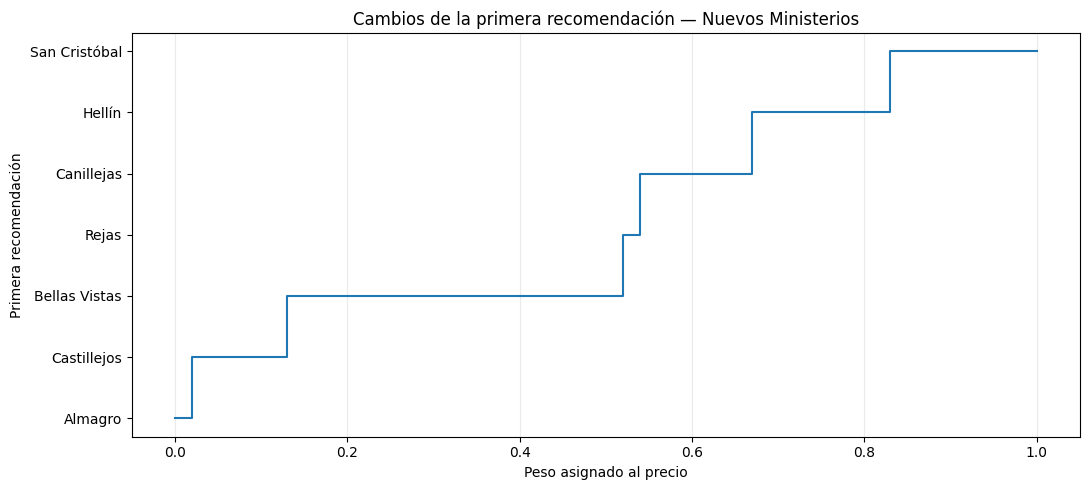

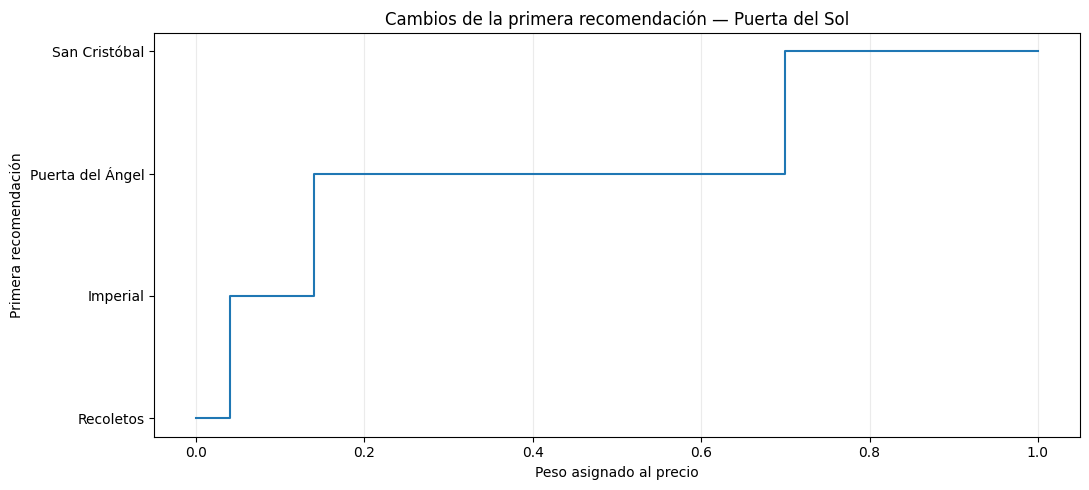

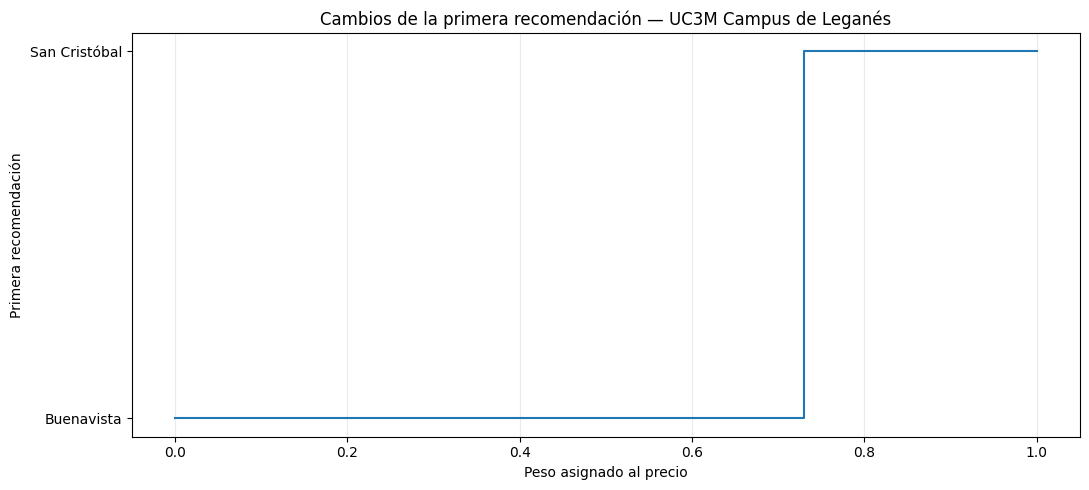

In [180]:
for destination_id, group in weight_stability_grid.groupby(
    "destination_id",
    sort=False,
):
    destination_name = group["destination_name"].iloc[0]

    # Se asigna un número a cada barrio para representar los cambios sin imponer un orden geográfico o económico inexistente.
    neighborhood_codes = {
        neighborhood: index
        for index, neighborhood in enumerate(
            group["top1_neighborhood_name"].drop_duplicates()
        )
    }

    y_values = group["top1_neighborhood_name"].map(
        neighborhood_codes
    )

    plt.figure(figsize=(11, 5))
    plt.step(
        group["price_weight"],
        y_values,
        where="post",
    )
    plt.yticks(
        list(neighborhood_codes.values()),
        list(neighborhood_codes.keys()),
    )
    plt.xlabel("Peso asignado al precio")
    plt.ylabel("Primera recomendación")
    plt.title(
        f"Cambios de la primera recomendación — {destination_name}"
    )
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Robustez frente a restricciones de precio y tiempo

Las restricciones se construyen con cuantiles de cada destino. Así evitamos aplicar el mismo límite absoluto a mercados y trayectos con escalas distintas.

Se combinan cinco niveles para el precio y cinco para el tiempo. En cada escenario se recalcula el frente de Pareto, porque una alternativa dominada en el conjunto completo puede dejar de estarlo después de excluir otras opciones.

In [181]:
CONSTRAINT_QUANTILES = [0.60, 0.70, 0.80, 0.90, 1.00]
constraint_rows = []

for destination_id in destination_catalog["destination_id"]:
    destination_frame = build_destination_frame(
        data,
        destination_id,
    )

    price_thresholds = {
        quantile: destination_frame[PRICE_COLUMN].quantile(quantile)
        for quantile in CONSTRAINT_QUANTILES
    }
    time_thresholds = {
        quantile: destination_frame[TIME_COLUMN].quantile(quantile)
        for quantile in CONSTRAINT_QUANTILES
    }

    for profile_id, profile in PROFILES.items():
        base_ranking, _ = rank_alternatives(
            source=data,
            destination=destination_id,
            method="pareto_weighted",
            price_weight=profile["price_weight"],
            time_weight=profile["time_weight"],
            top_n=TOP_K,
        )

        base_top1 = (
            base_ranking["zone_key"].iloc[0]
            if not base_ranking.empty
            else None
        )
        base_top_k = base_ranking["zone_key"].astype(str).tolist()

        for price_quantile, max_price in price_thresholds.items():
            for time_quantile, max_time in time_thresholds.items():
                ranking, audit = rank_alternatives(
                    source=data,
                    destination=destination_id,
                    method="pareto_weighted",
                    price_weight=profile["price_weight"],
                    time_weight=profile["time_weight"],
                    top_n=TOP_K,
                    max_price_m2=float(max_price),
                    max_commute_daily_minutes=float(max_time),
                )

                top1 = (
                    ranking["zone_key"].iloc[0]
                    if not ranking.empty
                    else None
                )
                top_k = ranking["zone_key"].astype(str).tolist()

                constraint_rows.append(
                    {
                        "destination_id": destination_id,
                        "destination_name": destination_frame[
                            "destination_name"
                        ].iloc[0],
                        "profile_id": profile_id,
                        "profile_name": profile["profile_name"],
                        "price_quantile": price_quantile,
                        "time_quantile": time_quantile,
                        "max_price_m2": max_price,
                        "max_commute_daily_minutes": max_time,
                        "eligible_alternatives": audit[
                            "eligible_alternatives"
                        ],
                        "feasible": not ranking.empty,
                        "top1_zone_key": top1,
                        "top1_neighborhood_name": (
                            ranking["neighborhood_name"].iloc[0]
                            if not ranking.empty
                            else None
                        ),
                        "top1_is_pareto": (
                            bool(
                                ranking["is_pareto_eligible"].iloc[0]
                            )
                            if not ranking.empty
                            else np.nan
                        ),
                        "base_top1_retained": top1 == base_top1,
                        "jaccard_vs_unconstrained": jaccard_at_k(
                            base_top_k,
                            top_k,
                        ),
                    }
                )

constraint_robustness = pd.DataFrame(constraint_rows)

display(constraint_robustness.head(10))

,destination_id,destination_name,profile_id,profile_name,price_quantile,time_quantile,max_price_m2,max_commute_daily_minutes,eligible_alternatives,feasible,top1_zone_key,top1_neighborhood_name,top1_is_pareto,base_top1_retained,jaccard_vs_unconstrained
0,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.6,0.6,5433.218,133.200000,29,True,MAD-202,Hellín,True,True,0.428571
1,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.6,0.7,5433.218,143.751667,40,True,MAD-202,Hellín,True,True,0.428571
2,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.6,0.8,5433.218,155.870000,49,True,MAD-202,Hellín,True,True,0.666667
3,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.6,0.9,5433.218,171.351667,61,True,MAD-202,Hellín,True,True,0.666667
4,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.6,1.0,5433.218,275.783333,74,True,MAD-202,Hellín,True,True,1.000000
5,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.7,0.6,5916.422,133.200000,41,True,MAD-202,Hellín,True,True,0.428571
6,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.7,0.7,5916.422,143.751667,52,True,MAD-202,Hellín,True,True,0.428571
7,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.7,0.8,5916.422,155.870000,62,True,MAD-202,Hellín,True,True,0.666667
8,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.7,0.9,5916.422,171.351667,74,True,MAD-202,Hellín,True,True,0.666667
9,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.7,1.0,5916.422,275.783333,87,True,MAD-202,Hellín,True,True,1.000000


In [182]:
constraint_robustness_summary = (
    constraint_robustness.groupby(
        ["destination_id", "destination_name", "profile_id", "profile_name"],
        as_index=False,
    )
    .agg(
        evaluated_scenarios=("feasible", "size"),
        feasible_scenarios=("feasible", "sum"),
        mean_eligible_alternatives=("eligible_alternatives", "mean"),
        minimum_eligible_alternatives=("eligible_alternatives", "min"),
        base_top1_retention_rate=("base_top1_retained", "mean"),
        mean_jaccard_vs_unconstrained=(
            "jaccard_vs_unconstrained",
            "mean",
        ),
        pareto_top1_rate=("top1_is_pareto", "mean"),
        unique_top1_neighborhoods=("top1_zone_key", "nunique"),
    )
)

constraint_robustness_summary["feasibility_rate"] = (
    constraint_robustness_summary["feasible_scenarios"]
    / constraint_robustness_summary["evaluated_scenarios"]
)

display(constraint_robustness_summary)

,destination_id,destination_name,profile_id,profile_name,evaluated_scenarios,feasible_scenarios,mean_eligible_alternatives,minimum_eligible_alternatives,base_top1_retention_rate,mean_jaccard_vs_unconstrained,pareto_top1_rate,unique_top1_neighborhoods,feasibility_rate
0,DEST_001,Puerta del Sol,balanced,Perfil equilibrado,25,25,72.48,30,1.0,0.866667,1.0,1,1.0
1,DEST_001,Puerta del Sol,price_priority,Prioridad al precio,25,25,72.48,30,0.6,0.771429,1.0,2,1.0
2,DEST_001,Puerta del Sol,time_priority,Prioridad al tiempo,25,25,72.48,30,1.0,0.819048,1.0,1,1.0
3,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,25,25,74.60,29,1.0,1.000000,1.0,1,1.0
4,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,25,25,74.60,29,1.0,0.638095,1.0,1,1.0
5,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,25,25,74.60,29,1.0,0.866667,1.0,1,1.0
6,DEST_003,UC3M Campus de Leganés,balanced,Perfil equilibrado,25,25,79.04,42,1.0,1.000000,1.0,1,1.0
7,DEST_003,UC3M Campus de Leganés,price_priority,Prioridad al precio,25,25,79.04,42,1.0,1.000000,1.0,1,1.0
8,DEST_003,UC3M Campus de Leganés,time_priority,Prioridad al tiempo,25,25,79.04,42,1.0,1.000000,1.0,1,1.0


In [183]:
constraint_global = pd.Series(
    {
        "evaluated_scenarios": len(constraint_robustness),
        "feasibility_rate": constraint_robustness["feasible"].mean(),
        "base_top1_retention_rate": constraint_robustness[
            "base_top1_retained"
        ].mean(),
        "mean_jaccard_vs_unconstrained": constraint_robustness[
            "jaccard_vs_unconstrained"
        ].mean(),
        "pareto_top1_rate": constraint_robustness.loc[
            constraint_robustness["feasible"],
            "top1_is_pareto",
        ].mean(),
    }
)

display(constraint_global.to_frame("value"))

display(
    Markdown(
        f"""
Se han evaluado **{int(constraint_global['evaluated_scenarios'])} escenarios de restricciones**. El sistema devuelve al menos una alternativa en el **{100 * constraint_global['feasibility_rate']:.2f} %** de ellos.

La primera recomendación sin restricciones se conserva en el **{100 * constraint_global['base_top1_retention_rate']:.2f} %** de los casos. Cuando cambia, la similitud media entre ambos `top {TOP_K}` es **{constraint_global['mean_jaccard_vs_unconstrained']:.3f}**.

Entre los escenarios factibles, la tasa de primeras recomendaciones Pareto-eficientes es del **{100 * constraint_global['pareto_top1_rate']:.2f} %**. Por tanto, endurecer los límites modifica el conjunto compatible, pero no elimina la comprobación de eficiencia.
"""
    )
)

,value
evaluated_scenarios,225.000000
feasibility_rate,1.000000
base_top1_retention_rate,0.955556
mean_jaccard_vs_unconstrained,0.884656
pareto_top1_rate,1.000000



Se han evaluado **225 escenarios de restricciones**. El sistema devuelve al menos una alternativa en el **100.00 %** de ellos.

La primera recomendación sin restricciones se conserva en el **95.56 %** de los casos. Cuando cambia, la similitud media entre ambos `top 5` es **0.885**.

Entre los escenarios factibles, la tasa de primeras recomendaciones Pareto-eficientes es del **100.00 %**. Por tanto, endurecer los límites modifica el conjunto compatible, pero no elimina la comprobación de eficiencia.


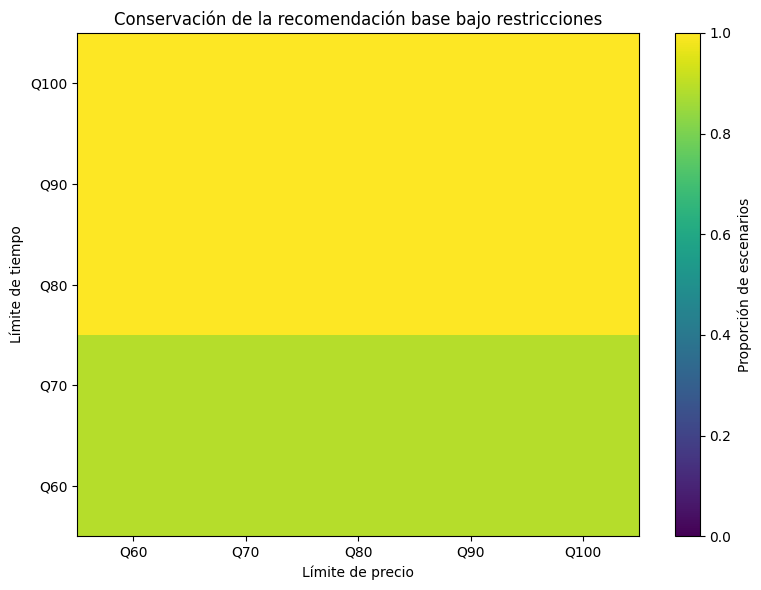

In [184]:
constraint_heatmap = (
    constraint_robustness.groupby(
        ["price_quantile", "time_quantile"],
        as_index=False,
    )["base_top1_retained"]
    .mean()
    .pivot(
        index="time_quantile",
        columns="price_quantile",
        values="base_top1_retained",
    )
    .sort_index(ascending=True)
)

plt.figure(figsize=(8, 6))
image = plt.imshow(
    constraint_heatmap.to_numpy(),
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
)
plt.xticks(
    range(len(constraint_heatmap.columns)),
    [f"Q{int(q * 100)}" for q in constraint_heatmap.columns],
)
plt.yticks(
    range(len(constraint_heatmap.index)),
    [f"Q{int(q * 100)}" for q in constraint_heatmap.index],
)
plt.xlabel("Límite de precio")
plt.ylabel("Límite de tiempo")
plt.title("Conservación de la recomendación base bajo restricciones")
plt.colorbar(image, label="Proporción de escenarios")
plt.tight_layout()
plt.show()

## 12. Robustez ante pequeños cambios en los datos

Los precios medios y los tiempos de desplazamiento no son valores completamente fijos. Pueden cambiar por la evolución del mercado, modificaciones en los horarios, incidencias en el transporte o diferencias entre distintas zonas de un mismo barrio.

Para comprobar cómo afectan estos cambios al recomendador, se introducen pequeñas variaciones aleatorias en el precio y en el tiempo. Estas variaciones pueden hacer que los valores aumenten o disminuyan ligeramente respecto a los datos originales.

Se prueban tres niveles de variación: 2 %, 5 % y 10 %. En cada simulación se vuelven a normalizar los datos, se calcula de nuevo el frente de Pareto y se genera un nuevo ranking.

Además, se fija una semilla aleatoria para que el experimento pueda repetirse y produzca los mismos resultados.


In [185]:
noise_frequency_rows = []
noise_summary_rows = []

In [186]:
# Se crea un generador independiente para que volver a ejecutar esta celda produzca exactamente los mismos resultados.
noise_rng = np.random.default_rng(RANDOM_SEED)

In [187]:
def perturbed_top_k_numpy(
    price_values: np.ndarray,
    time_values: np.ndarray,
    zone_keys: np.ndarray,
    price_weight: float,
    time_weight: float,
    top_k: int,
) -> np.ndarray:
    """
    Calcula el top k perturbado usando NumPy.

    Esta versión evita construir miles de DataFrames durante Monte Carlo.
    Mantiene la misma lógica del método principal: normalización por destino,
    filtrado Pareto y suma ponderada.
    """

    price_min = price_values.min()
    price_max = price_values.max()
    time_min = time_values.min()
    time_max = time_values.max()

    if np.isclose(price_max, price_min):
        price_normalized = np.zeros_like(price_values, dtype=float)
    else:
        price_normalized = (
            (price_values - price_min)
            / (price_max - price_min)
        )

    if np.isclose(time_max, time_min):
        time_normalized = np.zeros_like(time_values, dtype=float)
    else:
        time_normalized = (
            (time_values - time_min)
            / (time_max - time_min)
        )

    pareto_mask = pareto_mask_2d(
        price_values,
        time_values,
    )
    candidate_indices = np.flatnonzero(pareto_mask)

    candidate_scores = (
        price_weight * price_normalized[candidate_indices]
        + time_weight * time_normalized[candidate_indices]
    )

    # np.lexsort utiliza la última clave como criterio principal.
    order = np.lexsort(
        (
            zone_keys[candidate_indices],
            time_values[candidate_indices],
            price_values[candidate_indices],
            candidate_scores,
        )
    )

    selected_indices = candidate_indices[order[:top_k]]
    return zone_keys[selected_indices]

In [188]:
for destination_id in destination_catalog["destination_id"]:
    destination_frame = build_destination_frame(
        data,
        destination_id,
    )

    original_price = destination_frame[PRICE_COLUMN].to_numpy(dtype=float)
    original_time = destination_frame[TIME_COLUMN].to_numpy(dtype=float)
    zone_keys = destination_frame["zone_key"].astype(str).to_numpy()

    zone_metadata = (
        destination_frame[
            [
                "zone_key",
                "neighborhood_name",
                "district_name",
                "destination_name",
            ]
        ]
        .assign(zone_key=lambda frame: frame["zone_key"].astype(str))
        .set_index("zone_key")
    )

    for profile_id, profile in PROFILES.items():
        price_weight, time_weight = normalize_weights(
            profile["price_weight"],
            profile["time_weight"],
        )

        base_ranking, _ = rank_alternatives(
            source=data,
            destination=destination_id,
            method="pareto_weighted",
            price_weight=price_weight,
            time_weight=time_weight,
            top_n=TOP_K,
        )

        base_top1 = str(base_ranking["zone_key"].iloc[0])
        base_top_k_list = base_ranking[
            "zone_key"
        ].astype(str).tolist()
        base_top_k = set(base_top_k_list)

        for noise_level in NOISE_LEVELS:
            winner_counter: dict[str, int] = {}
            top_k_counter: dict[str, int] = {}
            base_top1_retained_count = 0
            base_top1_in_top_k_count = 0
            jaccard_values = []

            for iteration in range(MONTE_CARLO_ITERATIONS):
                price_noise = noise_rng.normal(
                    loc=0.0,
                    scale=noise_level,
                    size=len(original_price),
                )
                time_noise = noise_rng.normal(
                    loc=0.0,
                    scale=noise_level,
                    size=len(original_time),
                )

                perturbed_price = np.clip(
                    original_price * (1 + price_noise),
                    a_min=np.finfo(float).eps,
                    a_max=None,
                )
                perturbed_time = np.clip(
                    original_time * (1 + time_noise),
                    a_min=np.finfo(float).eps,
                    a_max=None,
                )

                top_k_array = perturbed_top_k_numpy(
                    price_values=perturbed_price,
                    time_values=perturbed_time,
                    zone_keys=zone_keys,
                    price_weight=price_weight,
                    time_weight=time_weight,
                    top_k=TOP_K,
                )

                top_k = top_k_array.astype(str).tolist()
                winner = top_k[0]

                winner_counter[winner] = winner_counter.get(winner, 0) + 1

                for zone_key in top_k:
                    top_k_counter[zone_key] = top_k_counter.get(zone_key, 0) + 1

                base_top1_retained_count += winner == base_top1
                base_top1_in_top_k_count += base_top1 in top_k
                jaccard_values.append(
                    jaccard_at_k(base_top_k, top_k)
                )

            winner_counts = pd.Series(winner_counter, dtype=int)

            # Se exportan todas las alternativas que han sido ganadoras o que han aparecido alguna vez dentro del top k.
            observed_zone_keys = sorted(
                set(winner_counter) | set(top_k_counter)
            )

            for zone_key in observed_zone_keys:
                metadata = zone_metadata.loc[zone_key]
                wins = winner_counter.get(zone_key, 0)
                top_k_appearances = top_k_counter.get(zone_key, 0)

                noise_frequency_rows.append(
                    {
                        "destination_id": destination_id,
                        "destination_name": metadata["destination_name"],
                        "profile_id": profile_id,
                        "profile_name": profile["profile_name"],
                        "noise_level": noise_level,
                        "zone_key": zone_key,
                        "neighborhood_name": metadata[
                            "neighborhood_name"
                        ],
                        "district_name": metadata["district_name"],
                        "winner_count": int(wins),
                        "winner_frequency": (
                            wins / MONTE_CARLO_ITERATIONS
                        ),
                        "top_k_count": int(top_k_appearances),
                        "top_k_frequency": (
                            top_k_appearances
                            / MONTE_CARLO_ITERATIONS
                        ),
                        "is_base_top1": zone_key == base_top1,
                    }
                )

            noise_summary_rows.append(
                {
                    "destination_id": destination_id,
                    "destination_name": destination_frame[
                        "destination_name"
                    ].iloc[0],
                    "profile_id": profile_id,
                    "profile_name": profile["profile_name"],
                    "noise_level": noise_level,
                    "iterations": MONTE_CARLO_ITERATIONS,
                    "base_top1_zone_key": base_top1,
                    "base_top1_neighborhood_name": base_ranking[
                        "neighborhood_name"
                    ].iloc[0],
                    "base_top1_retention_rate": (
                        base_top1_retained_count
                        / MONTE_CARLO_ITERATIONS
                    ),
                    "base_top1_in_top_k_rate": (
                        base_top1_in_top_k_count
                        / MONTE_CARLO_ITERATIONS
                    ),
                    "mean_jaccard_at_k": float(np.mean(jaccard_values)),
                    "unique_winners": len(winner_counter),
                    "winner_entropy": normalized_entropy(winner_counts),
                }
            )


In [189]:
noise_winner_frequency = pd.DataFrame(noise_frequency_rows)
noise_robustness_summary = pd.DataFrame(noise_summary_rows)

display(noise_robustness_summary.head(12))

,destination_id,destination_name,profile_id,profile_name,noise_level,iterations,base_top1_zone_key,base_top1_neighborhood_name,base_top1_retention_rate,base_top1_in_top_k_rate,mean_jaccard_at_k,unique_winners,winner_entropy
0,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.02,250,MAD-202,Hellín,0.972,0.992,0.864762,2,0.184261
1,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.05,250,MAD-202,Hellín,0.672,0.948,0.641714,6,0.557793
2,DEST_002,Nuevos Ministerios,price_priority,Prioridad al precio,0.10,250,MAD-202,Hellín,0.352,0.720,0.459079,17,0.693888
3,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,0.02,250,MAD-061,Bellas Vistas,0.504,1.000,0.911429,5,0.731174
4,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,0.05,250,MAD-061,Bellas Vistas,0.348,0.984,0.660667,5,0.920760
5,DEST_002,Nuevos Ministerios,balanced,Perfil equilibrado,0.10,250,MAD-061,Bellas Vistas,0.280,0.808,0.475905,15,0.698727
6,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,0.02,250,MAD-061,Bellas Vistas,0.996,1.000,0.901333,2,0.037622
7,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,0.05,250,MAD-061,Bellas Vistas,0.824,0.996,0.661667,3,0.520747
8,DEST_002,Nuevos Ministerios,time_priority,Prioridad al tiempo,0.10,250,MAD-061,Bellas Vistas,0.520,0.848,0.465429,8,0.628831
9,DEST_001,Puerta del Sol,price_priority,Prioridad al precio,0.02,250,MAD-172,San Cristóbal,0.916,1.000,0.780381,3,0.286588


### 12.1 Análisis de robustez

Comprobar si el mismo barrio sigue apareciendo siempre como primera opción es un criterio bastante exigente. Por eso, también se analiza con qué frecuencia la recomendación original se mantiene entre las cinco mejores y cuánto se parecen, en general, las listas obtenidas después de introducir pequeños cambios en los datos.


In [190]:
noise_global_summary = (
    noise_robustness_summary.groupby(
        "noise_level",
        as_index=False,
    )
    .agg(
        scenarios=("destination_id", "size"),
        mean_base_top1_retention_rate=(
            "base_top1_retention_rate",
            "mean",
        ),
        mean_base_top1_in_top_k_rate=(
            "base_top1_in_top_k_rate",
            "mean",
        ),
        mean_jaccard_at_k=("mean_jaccard_at_k", "mean"),
        mean_unique_winners=("unique_winners", "mean"),
        mean_winner_entropy=("winner_entropy", "mean"),
    )
)

In [191]:
display(noise_global_summary)

for _, row in noise_global_summary.iterrows():
    display(
        Markdown(
            f"""
Con perturbaciones del **{100 * row['noise_level']:.0f} %**, la primera recomendación original se mantiene en promedio en el **{100 * row['mean_base_top1_retention_rate']:.2f} %** de las iteraciones y continúa dentro del `top {TOP_K}` en el **{100 * row['mean_base_top1_in_top_k_rate']:.2f} %**.

La similitud media con la lista original es **{row['mean_jaccard_at_k']:.3f}** y aparecen **{row['mean_unique_winners']:.2f} ganadores distintos por escenario**. Como era esperable, un nivel mayor de perturbación puede reducir la estabilidad exacta sin implicar necesariamente que el conjunto de alternativas razonables desaparezca.
"""
        )
    )

,noise_level,scenarios,mean_base_top1_retention_rate,mean_base_top1_in_top_k_rate,mean_jaccard_at_k,mean_unique_winners,mean_winner_entropy
0,0.02,9,0.909778,0.999111,0.782117,2.444444,0.192741
1,0.05,9,0.729778,0.983111,0.602019,5.000000,0.452850
2,0.10,9,0.507111,0.863111,0.441149,13.222222,0.601208



Con perturbaciones del **2 %**, la primera recomendación original se mantiene en promedio en el **90.98 %** de las iteraciones y continúa dentro del `top 5` en el **99.91 %**.

La similitud media con la lista original es **0.782** y aparecen **2.44 ganadores distintos por escenario**. Como era esperable, un nivel mayor de perturbación puede reducir la estabilidad exacta sin implicar necesariamente que el conjunto de alternativas razonables desaparezca.



Con perturbaciones del **5 %**, la primera recomendación original se mantiene en promedio en el **72.98 %** de las iteraciones y continúa dentro del `top 5` en el **98.31 %**.

La similitud media con la lista original es **0.602** y aparecen **5.00 ganadores distintos por escenario**. Como era esperable, un nivel mayor de perturbación puede reducir la estabilidad exacta sin implicar necesariamente que el conjunto de alternativas razonables desaparezca.



Con perturbaciones del **10 %**, la primera recomendación original se mantiene en promedio en el **50.71 %** de las iteraciones y continúa dentro del `top 5` en el **86.31 %**.

La similitud media con la lista original es **0.441** y aparecen **13.22 ganadores distintos por escenario**. Como era esperable, un nivel mayor de perturbación puede reducir la estabilidad exacta sin implicar necesariamente que el conjunto de alternativas razonables desaparezca.


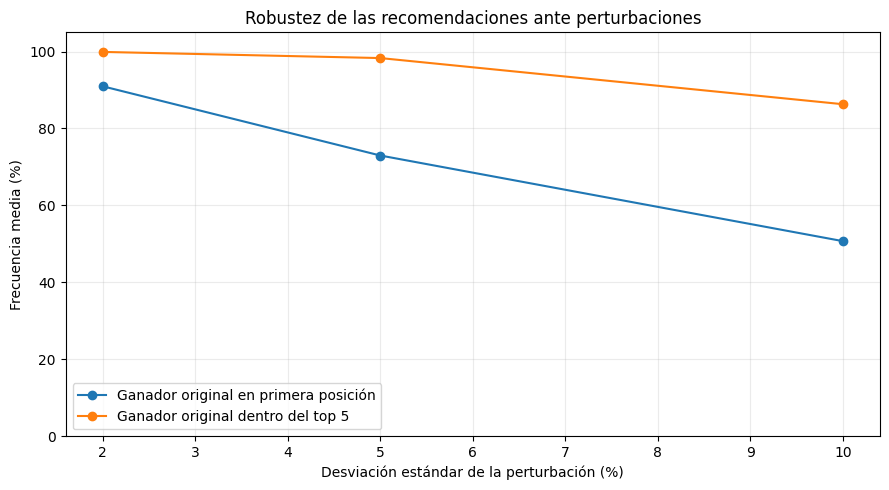

In [192]:
plt.figure(figsize=(9, 5))
plt.plot(
    100 * noise_global_summary["noise_level"],
    100 * noise_global_summary["mean_base_top1_retention_rate"],
    marker="o",
    label="Ganador original en primera posición",
)
plt.plot(
    100 * noise_global_summary["noise_level"],
    100 * noise_global_summary["mean_base_top1_in_top_k_rate"],
    marker="o",
    label=f"Ganador original dentro del top {TOP_K}",
)
plt.xlabel("Desviación estándar de la perturbación (%)")
plt.ylabel("Frecuencia media (%)")
plt.title("Robustez de las recomendaciones ante perturbaciones")
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Evaluación de las hipótesis

Se aplican criterios explícitos para resumir los resultados:

- H1 exige un 100 % de eficiencia en las recomendaciones del método principal.
- H2 exige una similitud media de Jaccard consecutiva de al menos 0,70.
- H3 exige que, con ruido del 5 %, el ganador original permanezca dentro del `top 5` al menos en el 80 % de las iteraciones.
- H4 exige que la primera recomendación cambie entre perfiles en al menos un destino.
- H5 exige eficiencia del 100 % en los escenarios de restricciones que siguen siendo factibles.

**NOTA:** Una hipótesis no superada no invalida el sistema. Señala una limitación concreta que debe explicarse en la memoria.

In [193]:
main_method_rows = method_comparison_detail.loc[
    method_comparison_detail["method"].eq("pareto_weighted")
]

In [194]:
# Hipótesis 1

h1_value = main_method_rows["is_pareto_eligible"].mean()
h1_passed = np.isclose(h1_value, 1.0)

In [195]:
# Hipótesis 2

h2_value = weight_stability_grid[
    "adjacent_jaccard_at_k"
].dropna().mean()
h2_passed = h2_value >= 0.70

In [196]:
# Hipótesis 3

noise_5 = noise_robustness_summary.loc[
    np.isclose(noise_robustness_summary["noise_level"], 0.05)
]
h3_value = noise_5["base_top1_in_top_k_rate"].mean()
h3_passed = h3_value >= 0.80

In [197]:
# Hipótesis 4

h4_value = int(
    profile_dependence.loc[
        profile_dependence["method"].eq("pareto_weighted"),
        "changes_with_profile",
    ].sum()
)
h4_passed = h4_value >= 1

In [198]:
# Hipótesis 5

h5_value = constraint_robustness.loc[
    constraint_robustness["feasible"],
    "top1_is_pareto",
].mean()
h5_passed = np.isclose(h5_value, 1.0)

In [199]:
hypothesis_results = pd.DataFrame(
    [
        {
            "hypothesis_id": "H1",
            "hypothesis": (
                "Las recomendaciones del método principal son "
                "Pareto-eficientes."
            ),
            "metric": "Pareto efficiency rate",
            "observed_value": h1_value,
            "acceptance_criterion": "= 1.00",
            "passed": h1_passed,
        },
        {
            "hypothesis_id": "H2",
            "hypothesis": (
                "El top 5 es estable ante cambios consecutivos "
                "pequeños en los pesos."
            ),
            "metric": "Mean adjacent Jaccard@5",
            "observed_value": h2_value,
            "acceptance_criterion": ">= 0.70",
            "passed": h2_passed,
        },
        {
            "hypothesis_id": "H3",
            "hypothesis": (
                "Con ruido del 5 %, el ganador original continúa "
                "habitualmente dentro del top 5."
            ),
            "metric": "Base top1 inclusion in top5",
            "observed_value": h3_value,
            "acceptance_criterion": ">= 0.80",
            "passed": h3_passed,
        },
        {
            "hypothesis_id": "H4",
            "hypothesis": (
                "La personalización cambia la primera recomendación "
                "en al menos un destino."
            ),
            "metric": "Destinations changing across profiles",
            "observed_value": float(h4_value),
            "acceptance_criterion": ">= 1",
            "passed": h4_passed,
        },
        {
            "hypothesis_id": "H5",
            "hypothesis": (
                "Las recomendaciones bajo restricciones continúan "
                "siendo Pareto-eficientes."
            ),
            "metric": "Constrained Pareto top1 rate",
            "observed_value": h5_value,
            "acceptance_criterion": "= 1.00",
            "passed": h5_passed,
        },
    ]
)

display(hypothesis_results)

,hypothesis_id,hypothesis,metric,observed_value,acceptance_criterion,passed
0,H1,Las recomendaciones del método principal son Pareto-eficientes.,Pareto efficiency rate,1.000000,= 1.00,True
1,H2,El top 5 es estable ante cambios consecutivos pequeños en los pesos.,Mean adjacent Jaccard@5,0.984444,>= 0.70,True
2,H3,"Con ruido del 5 %, el ganador original continúa habitualmente dentro del top 5.",Base top1 inclusion in top5,0.983111,>= 0.80,True
3,H4,La personalización cambia la primera recomendación en al menos un destino.,Destinations changing across profiles,3.000000,>= 1,True
4,H5,Las recomendaciones bajo restricciones continúan siendo Pareto-eficientes.,Constrained Pareto top1 rate,1.000000,= 1.00,True


In [200]:
passed_hypotheses = int(hypothesis_results["passed"].sum())
total_hypotheses = len(hypothesis_results)
failed_hypotheses = hypothesis_results.loc[
    ~hypothesis_results["passed"]
]

In [201]:
if failed_hypotheses.empty:
    failed_text = (
        "Todos los criterios operativos definidos para esta evaluación "
        "se han superado."
    )
else:
    failed_ids = ", ".join(
        failed_hypotheses["hypothesis_id"].astype(str)
    )
    failed_text = (
        f"No se superan los criterios de {failed_ids}. "
        "Esto debe interpretarse como una limitación observada, "
        "no ocultarse ni corregirse artificialmente."
    )

In [202]:
display(
    Markdown(
        f"""
Se superan **{passed_hypotheses} de {total_hypotheses} hipótesis operativas**.

{failed_text}
"""
    )
)


Se superan **5 de 5 hipótesis operativas**.

Todos los criterios operativos definidos para esta evaluación se han superado.


## 14. Validaciones automáticas

Las validaciones siguientes comprueban la integridad de los experimentos y evitan exportar resultados incoherentes.

In [203]:
validation_rows = []

In [204]:
def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )

In [205]:
add_validation(
    "unique_input_pairs",
    "Cada combinación barrio–destino es única.",
    not data.duplicated(["zone_key", "destination_id"]).any(),
    f"Filas de entrada: {len(data)}",
)

In [206]:
add_validation(
    "pareto_reproduction",
    "La comprobación independiente reproduce Pareto.",
    np.isclose(
        pareto_reproduction["match_percentage"],
        100,
    ).all(),
    (
        "Coincidencia mínima: "
        f"{pareto_reproduction['match_percentage'].min():.2f} %"
    ),
)

In [207]:
expected_method_groups = (
    len(destination_catalog)
    * len(PROFILES)
    * len(METHODS)
)

In [208]:
observed_method_groups = (
    method_comparison_detail[
        ["destination_id", "profile_id", "method"]
    ]
    .drop_duplicates()
    .shape[0]
)

In [209]:
valid_method_group_sizes = (
    method_comparison_detail.groupby(
        ["destination_id", "profile_id", "method"]
    )
    .size()
    .between(1, TOP_K)
    .all()
)

In [210]:
add_validation(
    "complete_method_comparison",
    "La comparación contiene todos los escenarios esperados.",
    (
        observed_method_groups == expected_method_groups
        and valid_method_group_sizes
    ),
    (
        f"Grupos esperados: {expected_method_groups}; "
        f"grupos obtenidos: {observed_method_groups}; "
        f"máximo permitido por grupo: {TOP_K}"
    ),
)

In [211]:
add_validation(
    "valid_rank_order",
    "Los rankings empiezan en 1 y no repiten posiciones.",
    (
        method_comparison_detail.groupby(
            ["destination_id", "profile_id", "method"]
        )["rank"]
        .apply(
            lambda values: values.tolist()
            == list(range(1, len(values) + 1))
        )
        .all()
    ),
    "Se comprueba cada combinación destino–perfil–método.",
)

In [212]:
add_validation(
    "main_method_pareto_efficiency",
    "El método principal no devuelve alternativas dominadas.",
    main_method_rows["is_pareto_eligible"].all(),
    (
        "Alternativas dominadas: "
        f"{int((~main_method_rows['is_pareto_eligible']).sum())}"
    ),
)

In [213]:
expected_weight_rows = (
    len(destination_catalog)
    * (number_of_weight_steps + 1)
)

In [214]:
add_validation(
    "complete_weight_grid",
    "La rejilla de pesos contiene todos los puntos esperados.",
    len(weight_stability_grid) == expected_weight_rows,
    (
        f"Esperadas: {expected_weight_rows}; "
        f"obtenidas: {len(weight_stability_grid)}"
    ),
)

In [215]:
expected_constraint_rows = (
    len(destination_catalog)
    * len(PROFILES)
    * len(CONSTRAINT_QUANTILES) ** 2
)

In [216]:
add_validation(
    "complete_constraint_grid",
    "La rejilla de restricciones está completa.",
    len(constraint_robustness) == expected_constraint_rows,
    (
        f"Esperadas: {expected_constraint_rows}; "
        f"obtenidas: {len(constraint_robustness)}"
    ),
)

In [217]:
expected_noise_summaries = (
    len(destination_catalog)
    * len(PROFILES)
    * len(NOISE_LEVELS)
)

In [218]:
add_validation(
    "complete_noise_experiment",
    "El experimento de ruido cubre todos los escenarios.",
    len(noise_robustness_summary) == expected_noise_summaries,
    (
        f"Esperadas: {expected_noise_summaries}; "
        f"obtenidas: {len(noise_robustness_summary)}"
    ),
)

In [219]:
add_validation(
    "noise_frequency_sums",
    "Las frecuencias de ganador suman uno por escenario.",
    (
        noise_winner_frequency.groupby(
            ["destination_id", "profile_id", "noise_level"]
        )["winner_frequency"]
        .sum()
        .pipe(lambda values: np.isclose(values, 1.0).all())
    ),
    "Tolerancia numérica aplicada con np.isclose.",
)

In [220]:
# Determinismo: misma entrada y configuración, mismo ranking.
first_run, _ = rank_alternatives(
    source=data,
    destination=destination_catalog["destination_id"].iloc[0],
    method="pareto_weighted",
    price_weight=0.63,
    time_weight=0.37,
    top_n=TOP_K,
)
second_run, _ = rank_alternatives(
    source=data,
    destination=destination_catalog["destination_id"].iloc[0],
    method="pareto_weighted",
    price_weight=0.63,
    time_weight=0.37,
    top_n=TOP_K,
)

In [221]:
add_validation(
    "deterministic_ranking",
    "El ranking es determinista.",
    first_run["zone_key"].tolist()
    == second_run["zone_key"].tolist(),
    "Dos ejecuciones idénticas producen el mismo orden.",
)

In [222]:
validation_report = pd.DataFrame(validation_rows)
display(validation_report)

,validation_id,description,passed,detail
0,unique_input_pairs,Cada combinación barrio–destino es única.,True,Filas de entrada: 371
1,pareto_reproduction,La comprobación independiente reproduce Pareto.,True,Coincidencia mínima: 100.00 %
2,complete_method_comparison,La comparación contiene todos los escenarios esperados.,True,Grupos esperados: 45; grupos obtenidos: 45; máximo permitido por grupo: 5
3,valid_rank_order,Los rankings empiezan en 1 y no repiten posiciones.,True,Se comprueba cada combinación destino–perfil–método.
4,main_method_pareto_efficiency,El método principal no devuelve alternativas dominadas.,True,Alternativas dominadas: 0
5,complete_weight_grid,La rejilla de pesos contiene todos los puntos esperados.,True,Esperadas: 303; obtenidas: 303
6,complete_constraint_grid,La rejilla de restricciones está completa.,True,Esperadas: 225; obtenidas: 225
7,complete_noise_experiment,El experimento de ruido cubre todos los escenarios.,True,Esperadas: 27; obtenidas: 27
8,noise_frequency_sums,Las frecuencias de ganador suman uno por escenario.,True,Tolerancia numérica aplicada con np.isclose.
9,deterministic_ranking,El ranking es determinista.,True,Dos ejecuciones idénticas producen el mismo orden.


In [223]:
failed_validations = validation_report.loc[
    ~validation_report["passed"]
]

if not failed_validations.empty:
    display(failed_validations)
    raise AssertionError(
        "La evaluación no supera todas las validaciones automáticas."
    )

print("Todas las validaciones automáticas se han superado.")

Todas las validaciones automáticas se han superado.


## 15. Exportación de resultados

Los archivos exportados permiten reutilizar las tablas directamente en la memoria, comparar ejecuciones y construir posteriormente una interfaz o un informe final.

In [224]:
method_comparison_detail.to_csv(
    METHOD_DETAIL_PATH,
    index=False,
    encoding="utf-8-sig",
)
method_comparison_summary.to_csv(
    METHOD_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
weight_stability_grid.to_csv(
    WEIGHT_GRID_PATH,
    index=False,
    encoding="utf-8-sig",
)
weight_stability_summary.to_csv(
    WEIGHT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
weight_intervals.to_csv(
    WEIGHT_INTERVALS_PATH,
    index=False,
    encoding="utf-8-sig",
)
constraint_robustness.to_csv(
    CONSTRAINT_DETAIL_PATH,
    index=False,
    encoding="utf-8-sig",
)
constraint_robustness_summary.to_csv(
    CONSTRAINT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
noise_winner_frequency.to_csv(
    NOISE_FREQUENCY_PATH,
    index=False,
    encoding="utf-8-sig",
)
noise_robustness_summary.to_csv(
    NOISE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
diversity_summary.to_csv(
    DIVERSITY_PATH,
    index=False,
    encoding="utf-8-sig",
)
hypothesis_results.to_csv(
    HYPOTHESES_PATH,
    index=False,
    encoding="utf-8-sig",
)
validation_report.to_csv(
    VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)

In [225]:
generated_paths = [
    METHOD_DETAIL_PATH,
    METHOD_SUMMARY_PATH,
    WEIGHT_GRID_PATH,
    WEIGHT_SUMMARY_PATH,
    WEIGHT_INTERVALS_PATH,
    CONSTRAINT_DETAIL_PATH,
    CONSTRAINT_SUMMARY_PATH,
    NOISE_FREQUENCY_PATH,
    NOISE_SUMMARY_PATH,
    DIVERSITY_PATH,
    HYPOTHESES_PATH,
    VALIDATION_PATH,
]

In [226]:
missing_exports = [
    path
    for path in generated_paths
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado correctamente todos los archivos: "
        f"{missing_exports}"
    )

print("Archivos generados correctamente:")

for path in generated_paths:
    print("-", path.relative_to(PROJECT_ROOT))

Archivos generados correctamente:
- data\results\evaluation_method_comparison_detail.csv
- data\results\evaluation_method_comparison_summary.csv
- data\results\evaluation_weight_stability_grid.csv
- data\results\evaluation_weight_stability_summary.csv
- data\results\evaluation_weight_stability_intervals.csv
- data\results\evaluation_constraint_robustness.csv
- data\results\evaluation_constraint_robustness_summary.csv
- data\results\evaluation_noise_winner_frequency.csv
- data\results\evaluation_noise_robustness_summary.csv
- data\results\evaluation_diversity_summary.csv
- data\results\evaluation_hypotheses.csv
- data\results\evaluation_validation_report.csv


## 16. Conclusiones finales

La celda siguiente resume automáticamente los principales resultados y evita escribir conclusiones que no coincidan con la ejecución real.

In [227]:
main_method_summary = method_comparison_summary.loc[
    method_comparison_summary["method"].eq("pareto_weighted")
].iloc[0]

In [228]:
mean_weight_jaccard = weight_stability_summary[
    "mean_adjacent_jaccard_at_k"
].mean()

In [229]:
top1_transitions_total = int(
    weight_stability_summary["top1_transitions"].sum()
)

In [230]:
noise_5_row = noise_global_summary.loc[
    np.isclose(noise_global_summary["noise_level"], 0.05)
].iloc[0]

In [231]:
conclusion_status = (
    "se superan todos los criterios definidos"
    if hypothesis_results["passed"].all()
    else (
        f"se superan {passed_hypotheses} de "
        f"{total_hypotheses} criterios definidos"
    )
)

In [232]:
display(
    Markdown(
        f"""
Este notebook ha evaluado el recomendador mediante **{len(method_comparison_detail)} resultados de comparación**, **{len(weight_stability_grid)} puntos de sensibilidad a los pesos**, **{len(constraint_robustness)} escenarios de restricciones** y **{len(noise_robustness_summary) * MONTE_CARLO_ITERATIONS:,} ejecuciones Monte Carlo**.

El método principal mantiene una eficiencia Pareto del **{main_method_summary['pareto_efficiency_rate']:.2f} %** en el conjunto de recomendaciones analizado. La comparación con la suma ponderada sin filtro muestra que Pareto no se utiliza como un adorno: permite excluir alternativas dominadas, mantener la trazabilidad del proceso y garantizar que el usuario solo compare compromisos eficientes.

La sensibilidad a los pesos presenta una similitud media consecutiva de **{mean_weight_jaccard:.3f}** en el `top {TOP_K}` y acumula **{top1_transitions_total} transiciones de primera recomendación** entre todos los destinos. Los cambios se concentran en intervalos concretos, lo que permite explicar en qué punto una mayor prioridad al precio o al tiempo modifica la decisión.

Ante perturbaciones del **5 %**, el ganador original permanece dentro del `top {TOP_K}` en el **{100 * noise_5_row['mean_base_top1_in_top_k_rate']:.2f} %** de las simulaciones. Esta medida es más informativa que exigir que la primera posición sea inmutable, ya que varias alternativas próximas pueden intercambiarse sin dejar de representar compromisos razonables.

La evaluación de restricciones confirma una tasa de factibilidad del **{100 * constraint_global['feasibility_rate']:.2f} %** en la rejilla estudiada y una eficiencia Pareto del **{100 * constraint_global['pareto_top1_rate']:.2f} %** entre los escenarios factibles.

**{conclusion_status}**. Como limitación, el experimento perturba precio y tiempo mediante ruido estadístico simplificado. No sustituye a una validación temporal con nuevos anuncios ni a la observación de tiempos reales de transporte. Estas extensiones pueden plantearse como trabajo futuro.
"""
    )
)


Este notebook ha evaluado el recomendador mediante **225 resultados de comparación**, **303 puntos de sensibilidad a los pesos**, **225 escenarios de restricciones** y **6,750 ejecuciones Monte Carlo**.

El método principal mantiene una eficiencia Pareto del **100.00 %** en el conjunto de recomendaciones analizado. La comparación con la suma ponderada sin filtro muestra que Pareto no se utiliza como un adorno: permite excluir alternativas dominadas, mantener la trazabilidad del proceso y garantizar que el usuario solo compare compromisos eficientes.

La sensibilidad a los pesos presenta una similitud media consecutiva de **0.984** en el `top 5` y acumula **10 transiciones de primera recomendación** entre todos los destinos. Los cambios se concentran en intervalos concretos, lo que permite explicar en qué punto una mayor prioridad al precio o al tiempo modifica la decisión.

Ante perturbaciones del **5 %**, el ganador original permanece dentro del `top 5` en el **98.31 %** de las simulaciones. Esta medida es más informativa que exigir que la primera posición sea inmutable, ya que varias alternativas próximas pueden intercambiarse sin dejar de representar compromisos razonables.

La evaluación de restricciones confirma una tasa de factibilidad del **100.00 %** en la rejilla estudiada y una eficiencia Pareto del **100.00 %** entre los escenarios factibles.

**se superan todos los criterios definidos**. Como limitación, el experimento perturba precio y tiempo mediante ruido estadístico simplificado. No sustituye a una validación temporal con nuevos anuncios ni a la observación de tiempos reales de transporte. Estas extensiones pueden plantearse como trabajo futuro.


In [233]:
final_summary = pd.Series(
    {
        "input_rows": len(data),
        "neighborhoods": data["zone_key"].nunique(),
        "destinations": data["destination_id"].nunique(),
        "profiles": len(PROFILES),
        "methods": len(METHODS),
        "method_comparison_rows": len(method_comparison_detail),
        "weight_grid_rows": len(weight_stability_grid),
        "constraint_scenarios": len(constraint_robustness),
        "monte_carlo_runs": (
            len(noise_robustness_summary)
            * MONTE_CARLO_ITERATIONS
        ),
        "hypotheses_passed": passed_hypotheses,
        "hypotheses_total": total_hypotheses,
        "validations_passed": int(validation_report["passed"].sum()),
        "validations_total": len(validation_report),
        "exported_files": len(generated_paths),
    }
)

In [234]:
display(final_summary.to_frame("value"))

print("\nNotebook 10 finalizado correctamente.")

,value
input_rows,371
neighborhoods,128
destinations,3
profiles,3
methods,5
method_comparison_rows,225
weight_grid_rows,303
constraint_scenarios,225
monte_carlo_runs,6750
hypotheses_passed,5



Notebook 10 finalizado correctamente.
